In [126]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [234]:
suppressPackageStartupMessages({
  # --- Core Tidyverse (dplyr, tidyr, ggplot2, readr, stringr, purrr, forcats) ---
  library(tidyverse)
  
  # --- Genomics & BioConductor ---
  library(GenomicRanges)
  library(IRanges)
  library(S4Vectors)
  library(ComplexHeatmap)
  library(circlize)
  
  # --- Visualization Enhancements ---
  library(ggforce)       # For geom_sina
  library(ggpubr)        # For stat_compare_means
  library(viridis)       # Color scales
  
  # --- Utilities ---
  library(gtools)        # For mixedsort
  library(tibble)
})

In [235]:

####### Load COPYDNA CNVs segmentation file
cnv <- read.table("Mean_normalized_v3_tab.seg", header = TRUE, sep = "\t")
head(cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<int>,<int>,<int>,<int>,<dbl>
1,2436A,1,200151,28021140,130,0.0534
2,2436A,1,142707663,142907814,2,1.3533
3,2436A,10,88303635,101719380,68,0.0066
4,2436A,10,101919615,104722905,15,-0.1040
5,2436A,10,104923140,112932540,41,-0.0198
6,2436A,10,113132775,120741705,39,-0.4022


In [129]:

# Check distribution
summary(cnv$seg.mean)

# Estimate neutral baseline (median ~ 0)
baseline <- median(cnv$seg.mean, na.rm = TRUE)
mad_val  <- mad(cnv$seg.mean, na.rm = TRUE)

# Thresholds
loss_thr  <- baseline - 2 * mad_val
gain_thr  <- baseline + 2 * mad_val

loss_thr; gain_thr


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4244 -0.1263  0.0000  0.0495  0.3638  2.3108 

[1] -0.3822143

[1] 0.3822143

In [130]:
cnv <- cnv %>%
  mutate(
    Length = loc.end - loc.start,
    CNV_status = case_when(
      seg.mean >= 0.2 ~ "Gain",
      seg.mean <= -0.2 ~ "Loss",
      TRUE ~ "Neutral"
    )
  )


In [131]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)


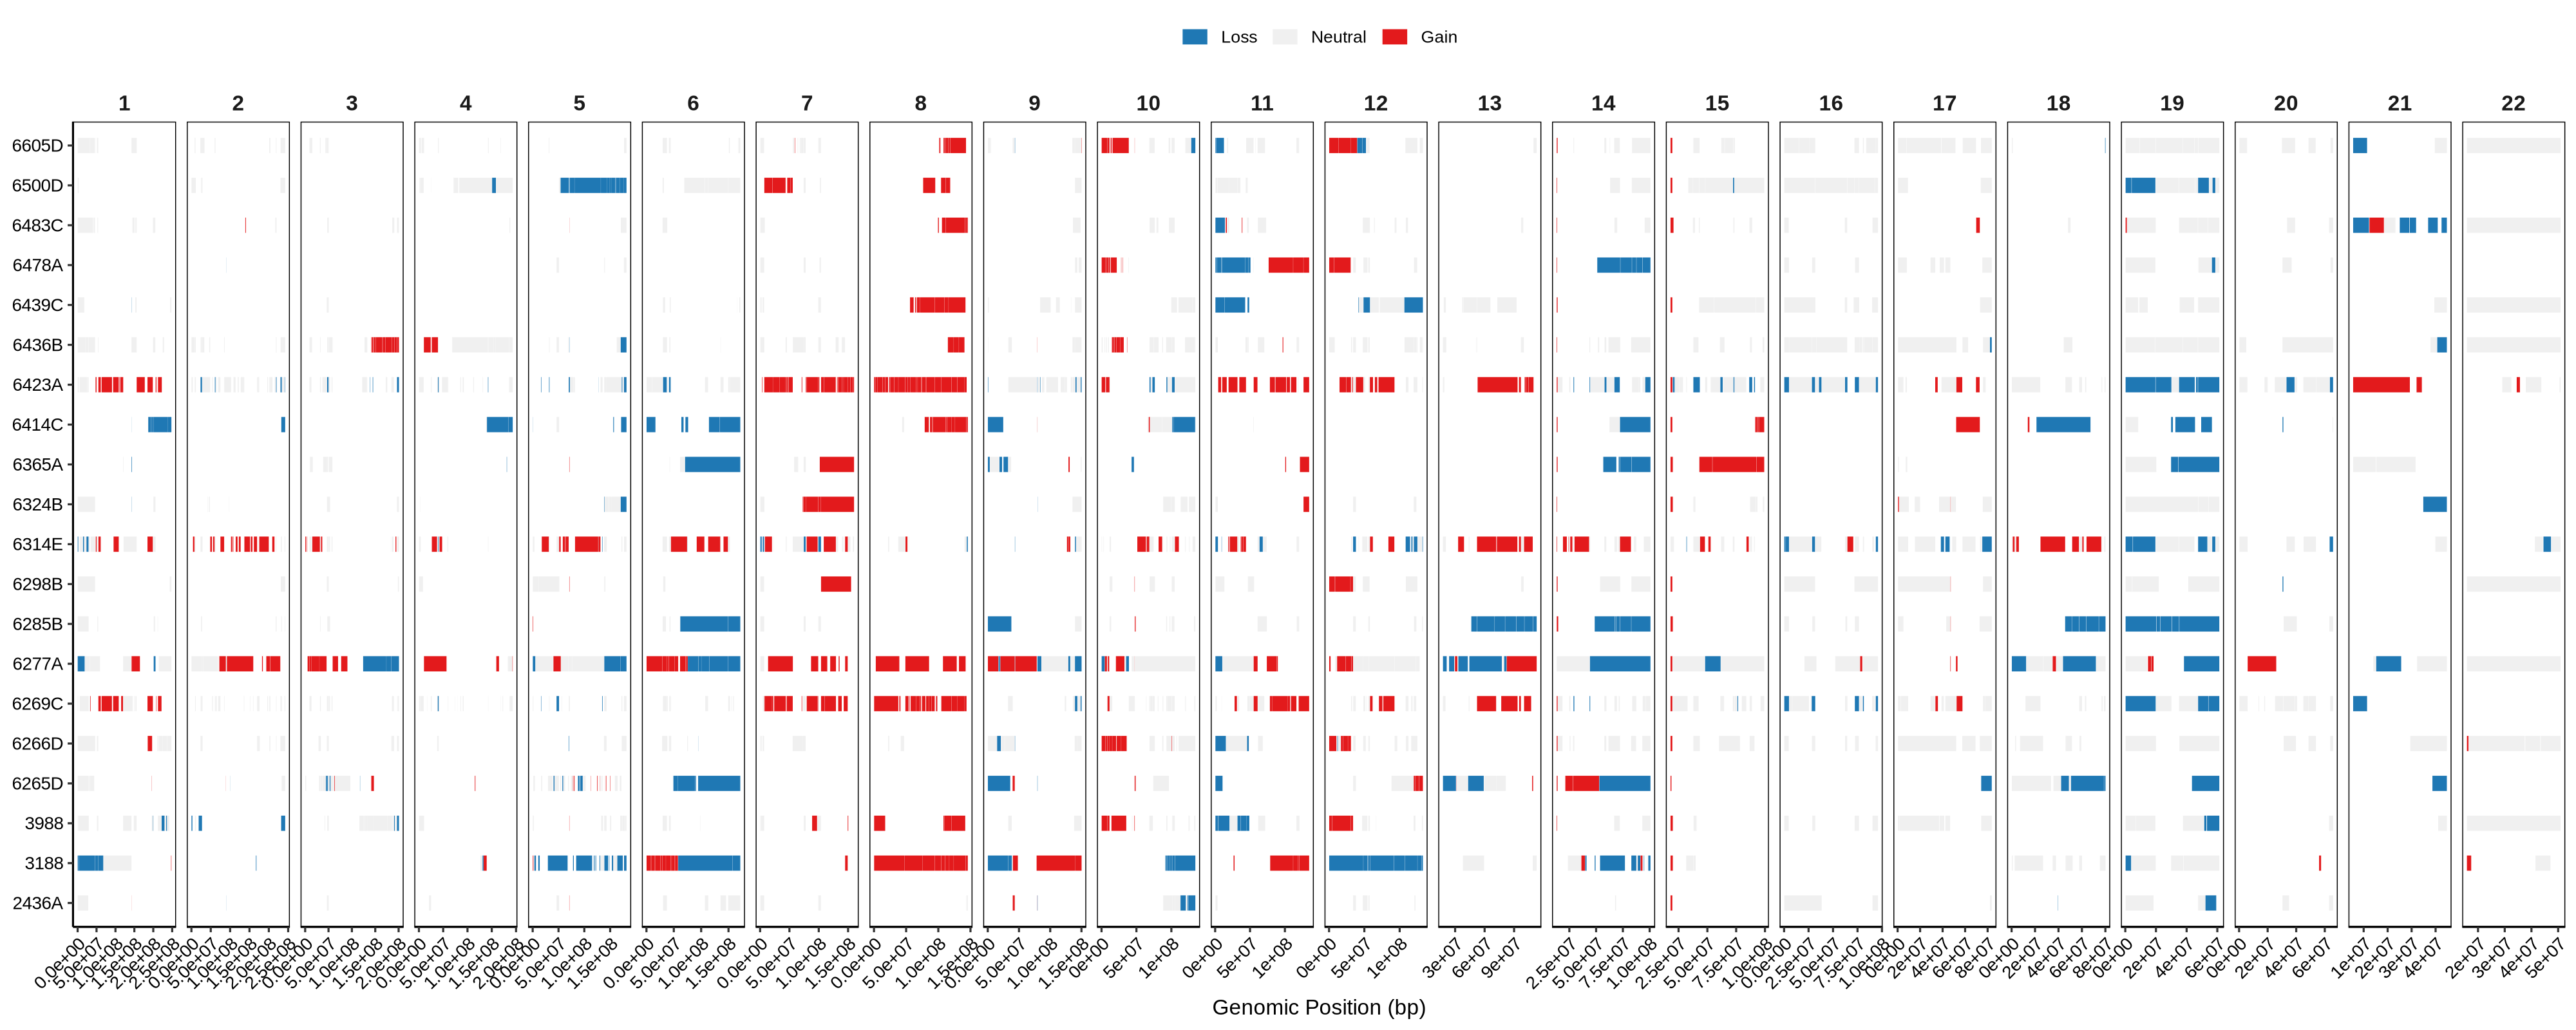

In [132]:

# Ensure CNV_status is a factor
cnv$CNV_status <- factor(cnv$CNV_status, levels = c("Loss", "Neutral", "Gain"))


colors <- c("Loss" = "#1f78b4", "Neutral" = "#f0f0f0", "Gain" = "#e31a1c")
    options(repr.plot.width = 20, repr.plot.height = 8, repr.plot.res = 200)

# Plot CNVs faceted per chromosome in a single row
ggplot(cnv, aes(x = loc.start, xend = loc.end, y = ID, yend = ID, color = CNV_status)) +
  geom_segment(size = 4) +
  scale_color_manual(values = colors) +
  facet_wrap(~ chrom, scales = "free_x", nrow = 1) +  # single row
  theme_classic(base_size = 12) +
  labs(x = "Genomic Position (bp)", y = NULL, color = NULL) +
  theme(
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(size = 10, color = "black", angle = 45, hjust = 1),
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "top",
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )


In [133]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)


In [134]:
head(cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<fct>
1,2436A,1,200151,28021140,130,0.0534,27820989,Neutral
2,2436A,1,142707663,142907814,2,1.3533,200151,Gain
3,2436A,10,88303635,101719380,68,0.0066,13415745,Neutral
4,2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral
5,2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral
6,2436A,10,113132775,120741705,39,-0.4022,7608930,Loss


In [135]:

# 1. Define ecDNA based on literature rules (MAD-based, length ≥100kb)
cnv_ecdna <- cnv %>%
  group_by(ID) %>%
  mutate(
    med_seg = median(seg.mean, na.rm = TRUE),       # median segment mean per sample
    mad_seg = mad(seg.mean, na.rm = TRUE),          # MAD per sample
    #ecDNA_flag = ifelse(seg.mean > med_seg + 3*mad_seg & Length >= 100000, 1, 0),  # literature rules
    ecDNA_flag = ifelse(seg.mean > med_seg + 4*mad_seg & Length >= 1000 & Length <= 5e6, 1, 0),  # add max size 5 Mb
    CNV_status = case_when(
      seg.mean >= 0.2 ~ "Gain",
      seg.mean <= -0.2 ~ "Loss",
      TRUE ~ "Neutral"
    )
  ) %>%
  ungroup()

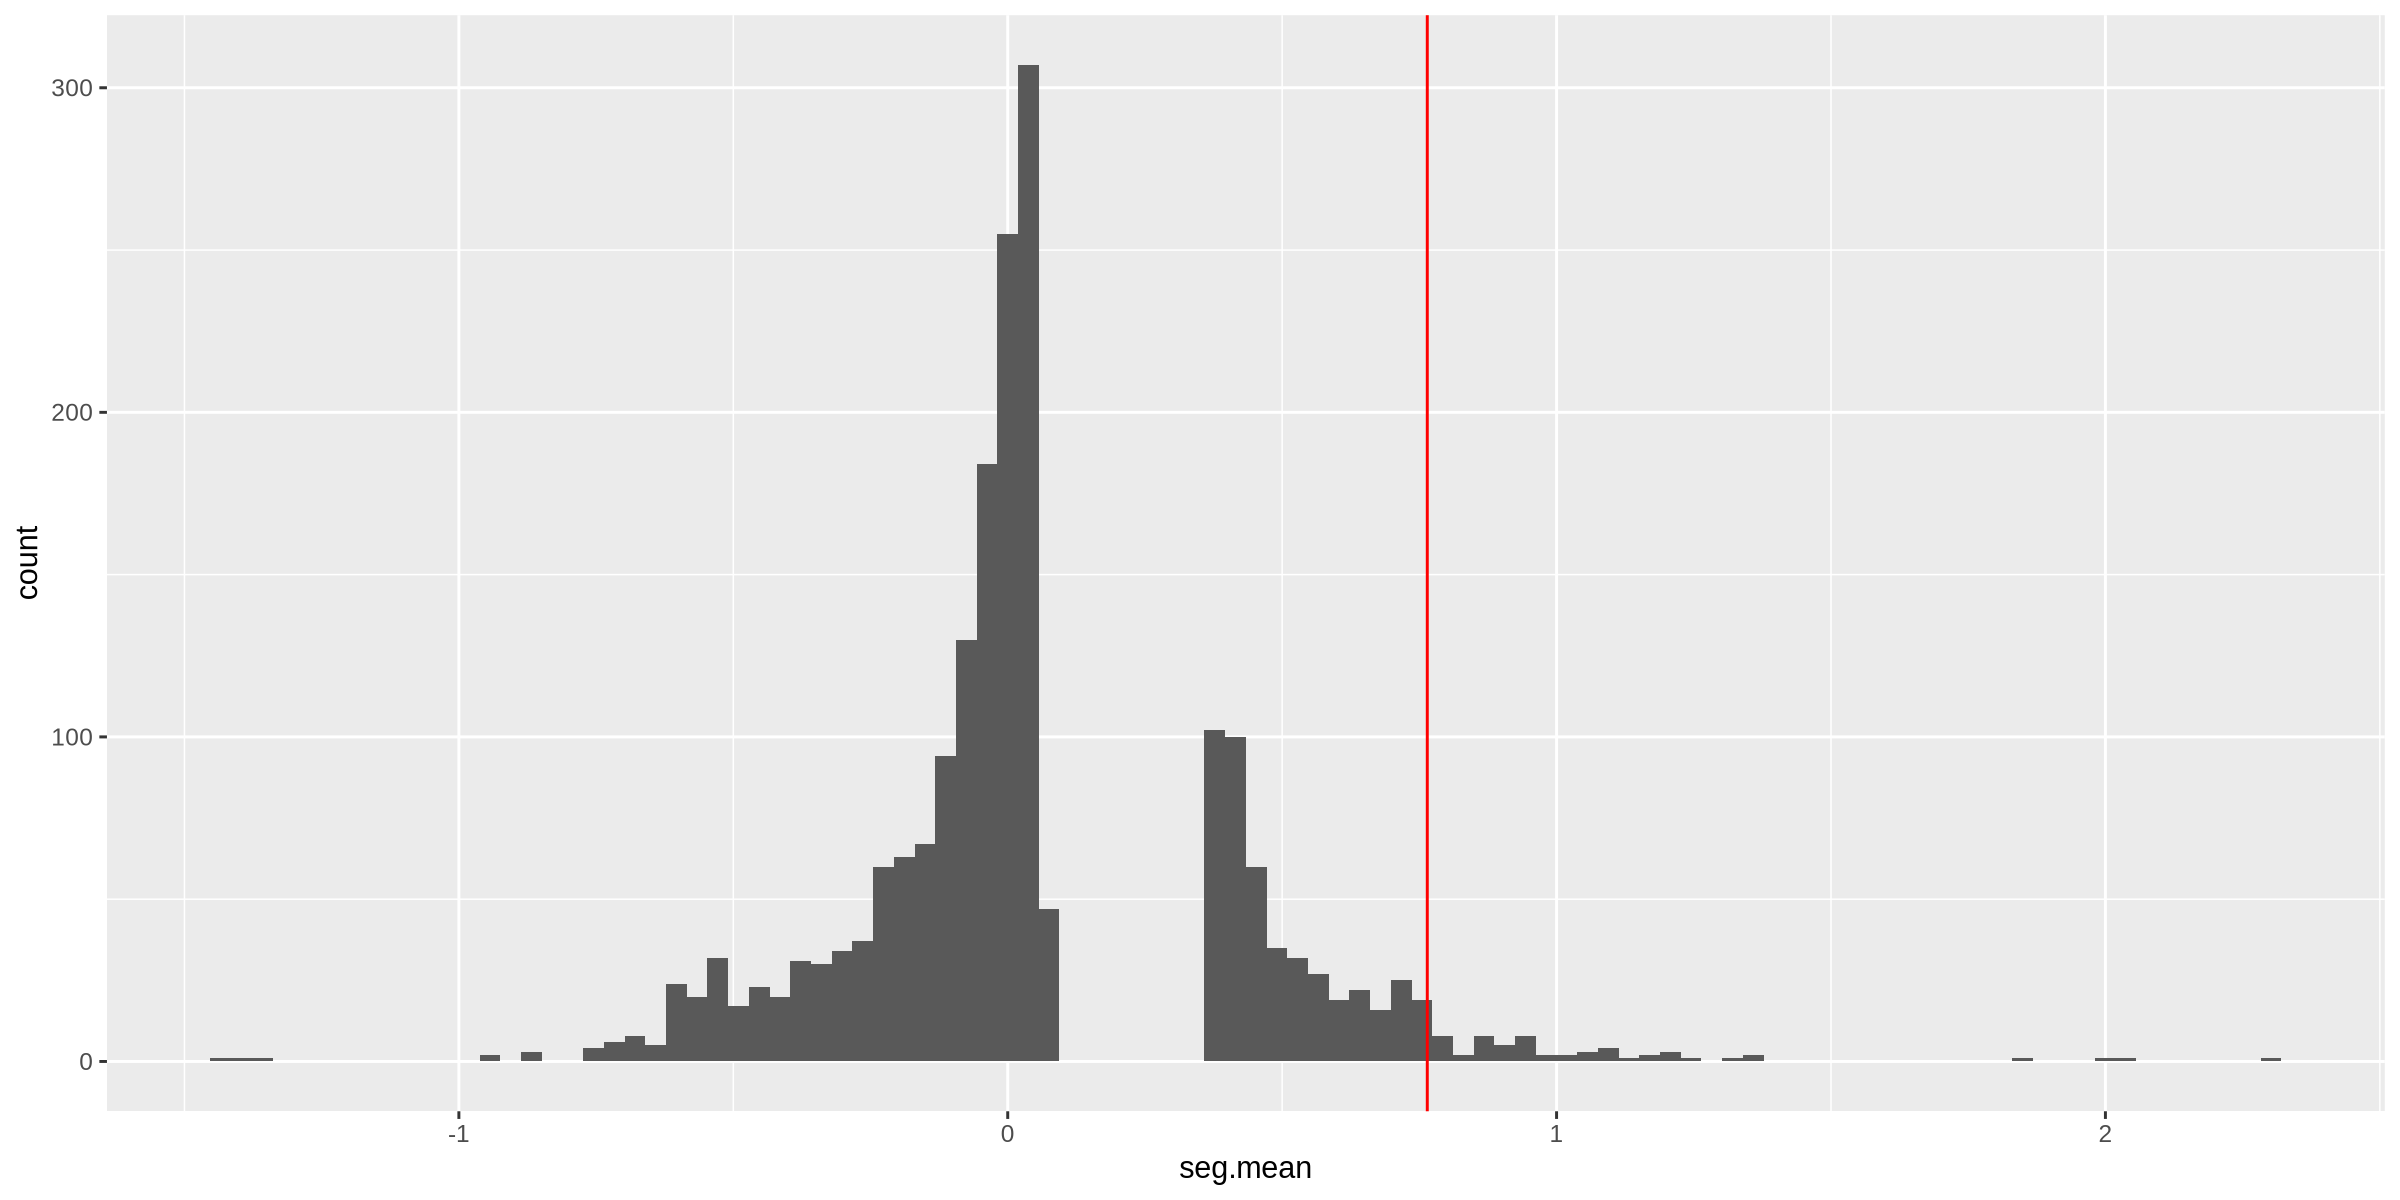

In [136]:
p <- ggplot(cnv, aes(x=seg.mean)) +
  geom_histogram(bins=100) +
  geom_vline(aes(xintercept = median(seg.mean) + 4*mad(seg.mean)), color="red")
p

In [137]:
# Save the plot
ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/threshold_ecDNa.pdf",
  plot = p,
  width = 10,
  height = 5,
  dpi = 200
)


ERROR: Error in ggsave(plot = p, width = 10, height = 5, dpi = 200): argument "filename" is missing, with no default


In [ ]:
# 2. Summarize ecDNA per sample and chromosome
ecdna_summary <- cnv_ecdna %>%
  filter(ecDNA_flag == 1) %>%
  group_by(ID, chrom) %>%
  summarize(
    total_ecDNA_length = sum(Length),
    n_ecDNA_segments = n(),
    max_ecDNA_length = max(Length, na.rm = TRUE)
  ) %>%
  ungroup()

# 3. Optional: plot CNV heatmap with ecDNA highlighted
colors <- c("Loss" = "#1f78b4", "Neutral" = "#f0f0f0", "Gain" = "#e31a1c")

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

p <- ggplot(cnv_ecdna, aes(x = loc.start, xend = loc.end, y = ID, yend = ID)) +
  geom_segment(aes(color = CNV_status), size = 4) +
  geom_segment(data = filter(cnv_ecdna, ecDNA_flag == 1),
               aes(x = loc.start, xend = loc.end, y = ID, yend = ID),
               color = "gold", size = 4) +  # ecDNA highlighted
  scale_color_manual(values = colors) +
  facet_wrap(~ chrom, scales = "free_x", nrow = 1) +
  theme_classic(base_size = 12) +
  labs(x = "Genomic Position (bp)", y = NULL, color = NULL) +
  theme(
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "top",
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )
p

In [138]:
unique(cnv_ecdna$chrom)


[1]  1 10 11 12 14 15 16 17 18 19  2 20  3  4  5  6  7  8  9 13 22 21

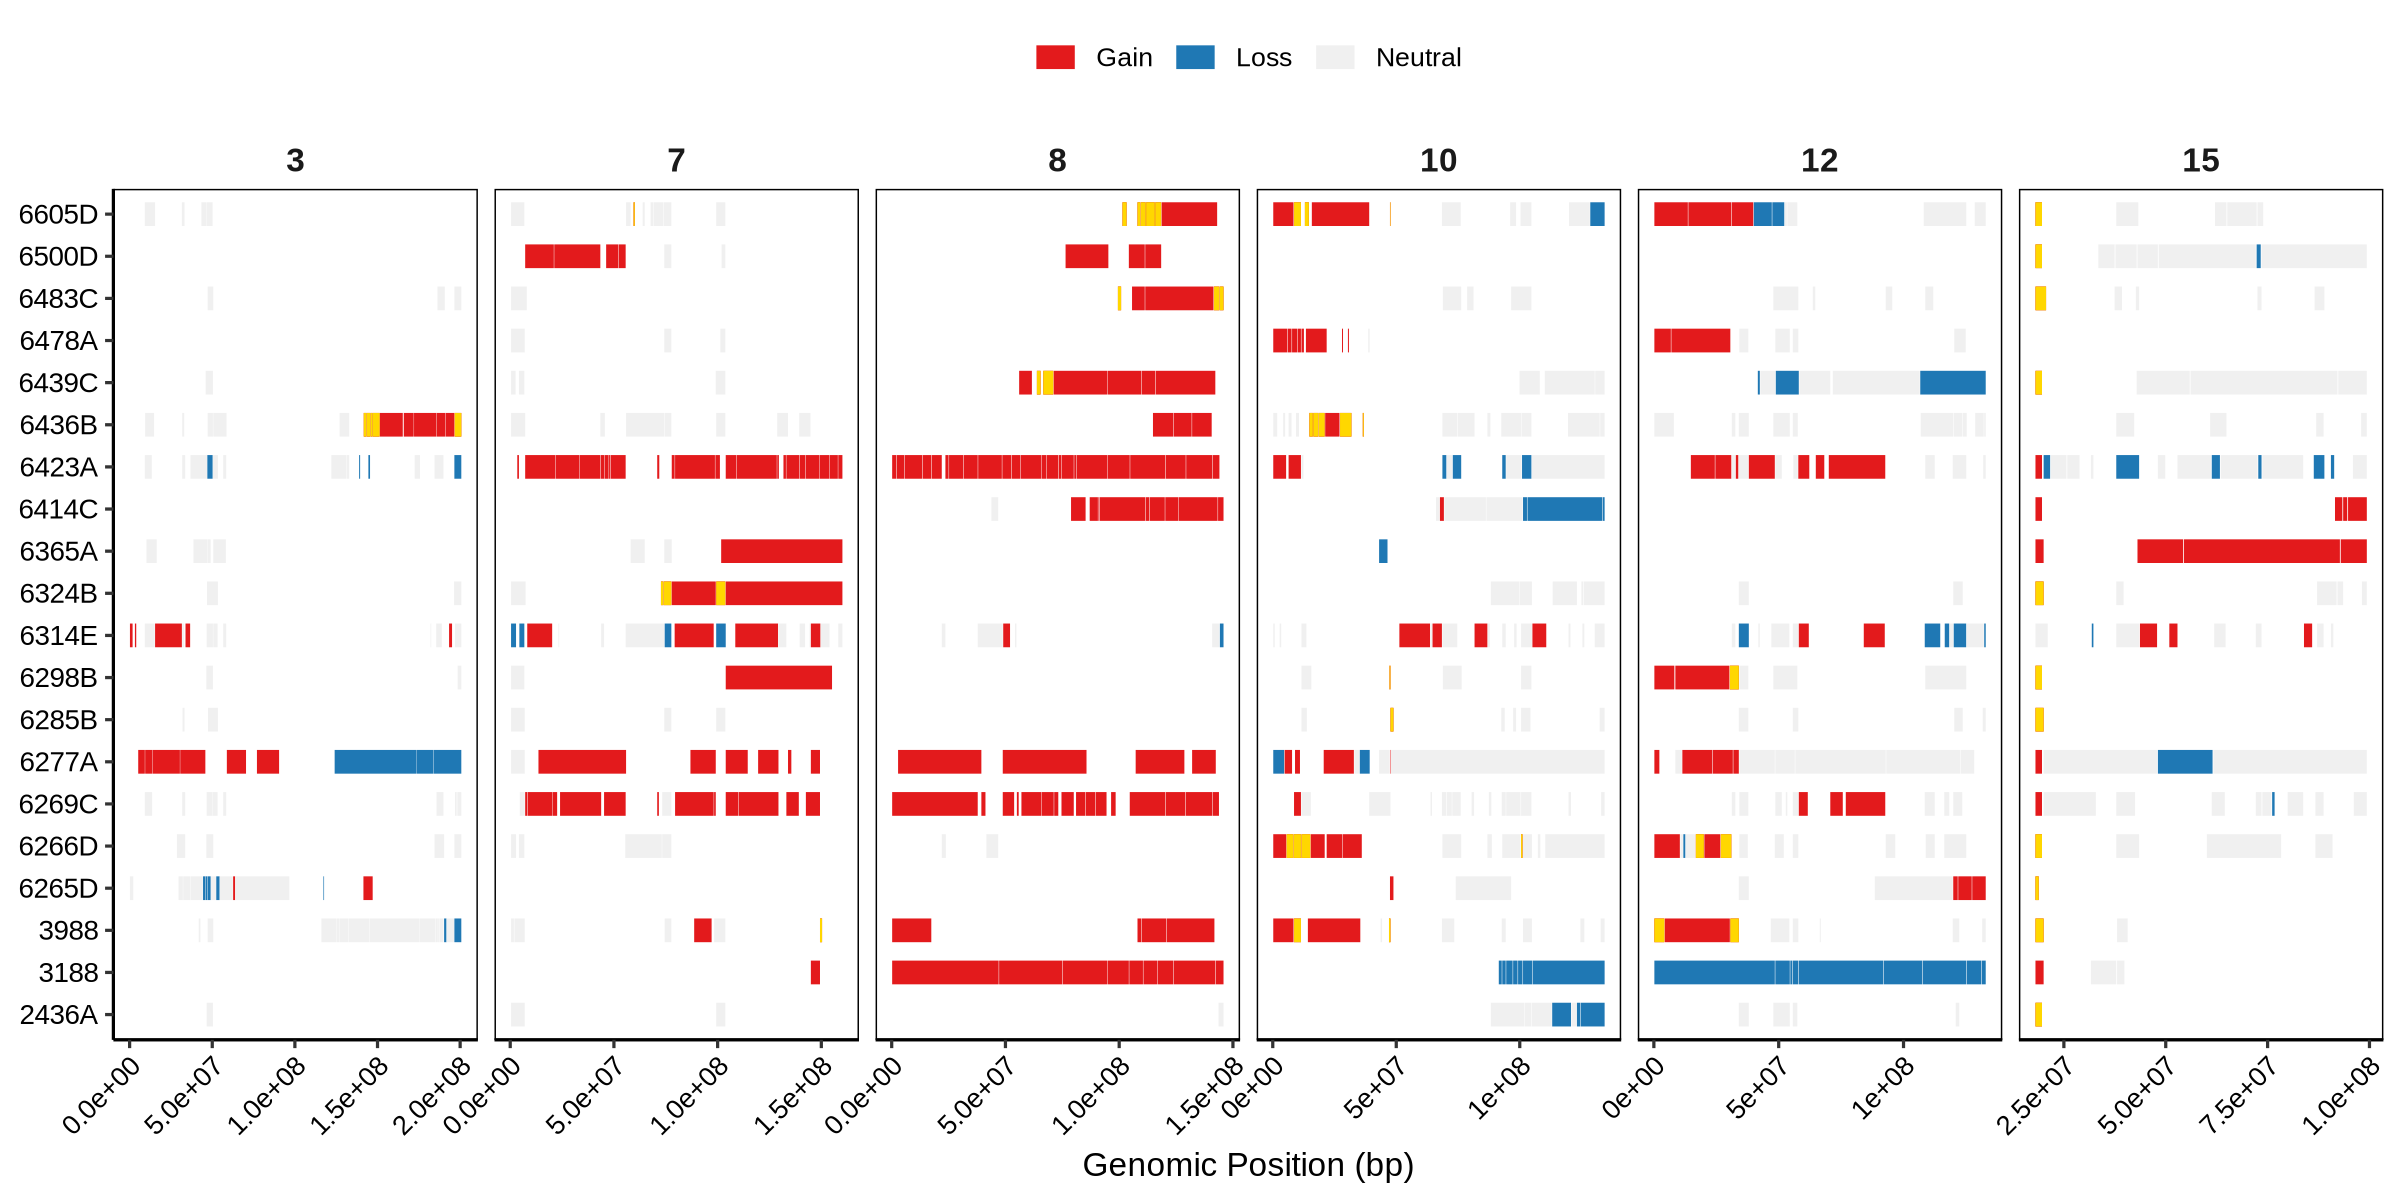

In [139]:
# Selected chromosomes in desired order
selected_chroms <- c("3", "7", "8", "10", "12", "15")

# Filter and set factor order
cnv_filtered <- cnv_ecdna %>%
  filter(chrom %in% selected_chroms) %>%
  mutate(chrom = factor(chrom, levels = selected_chroms))

# Plot
p <- ggplot(cnv_filtered, aes(x = loc.start, xend = loc.end, y = ID, yend = ID)) +
  geom_segment(aes(color = CNV_status), size = 4) +
  geom_segment(data = filter(cnv_filtered, ecDNA_flag == 1),
               aes(x = loc.start, xend = loc.end, y = ID, yend = ID),
               color = "gold", size = 4) +  # ecDNA highlighted
  scale_color_manual(values = colors) +
  facet_wrap(~ chrom, scales = "free_x", nrow = 1) +
  theme_classic(base_size = 12) +
  labs(x = "Genomic Position (bp)", y = NULL, color = NULL) +
  theme(
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "top",
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )

p


In [140]:
head(cnv_ecdna)

ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>
2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0
2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1
2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0
2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0
2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0
2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0


In [141]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/heatmap_ecDNa.pdf",
  plot = p,
  width = 12,
  height = 6,
  dpi = 200
)


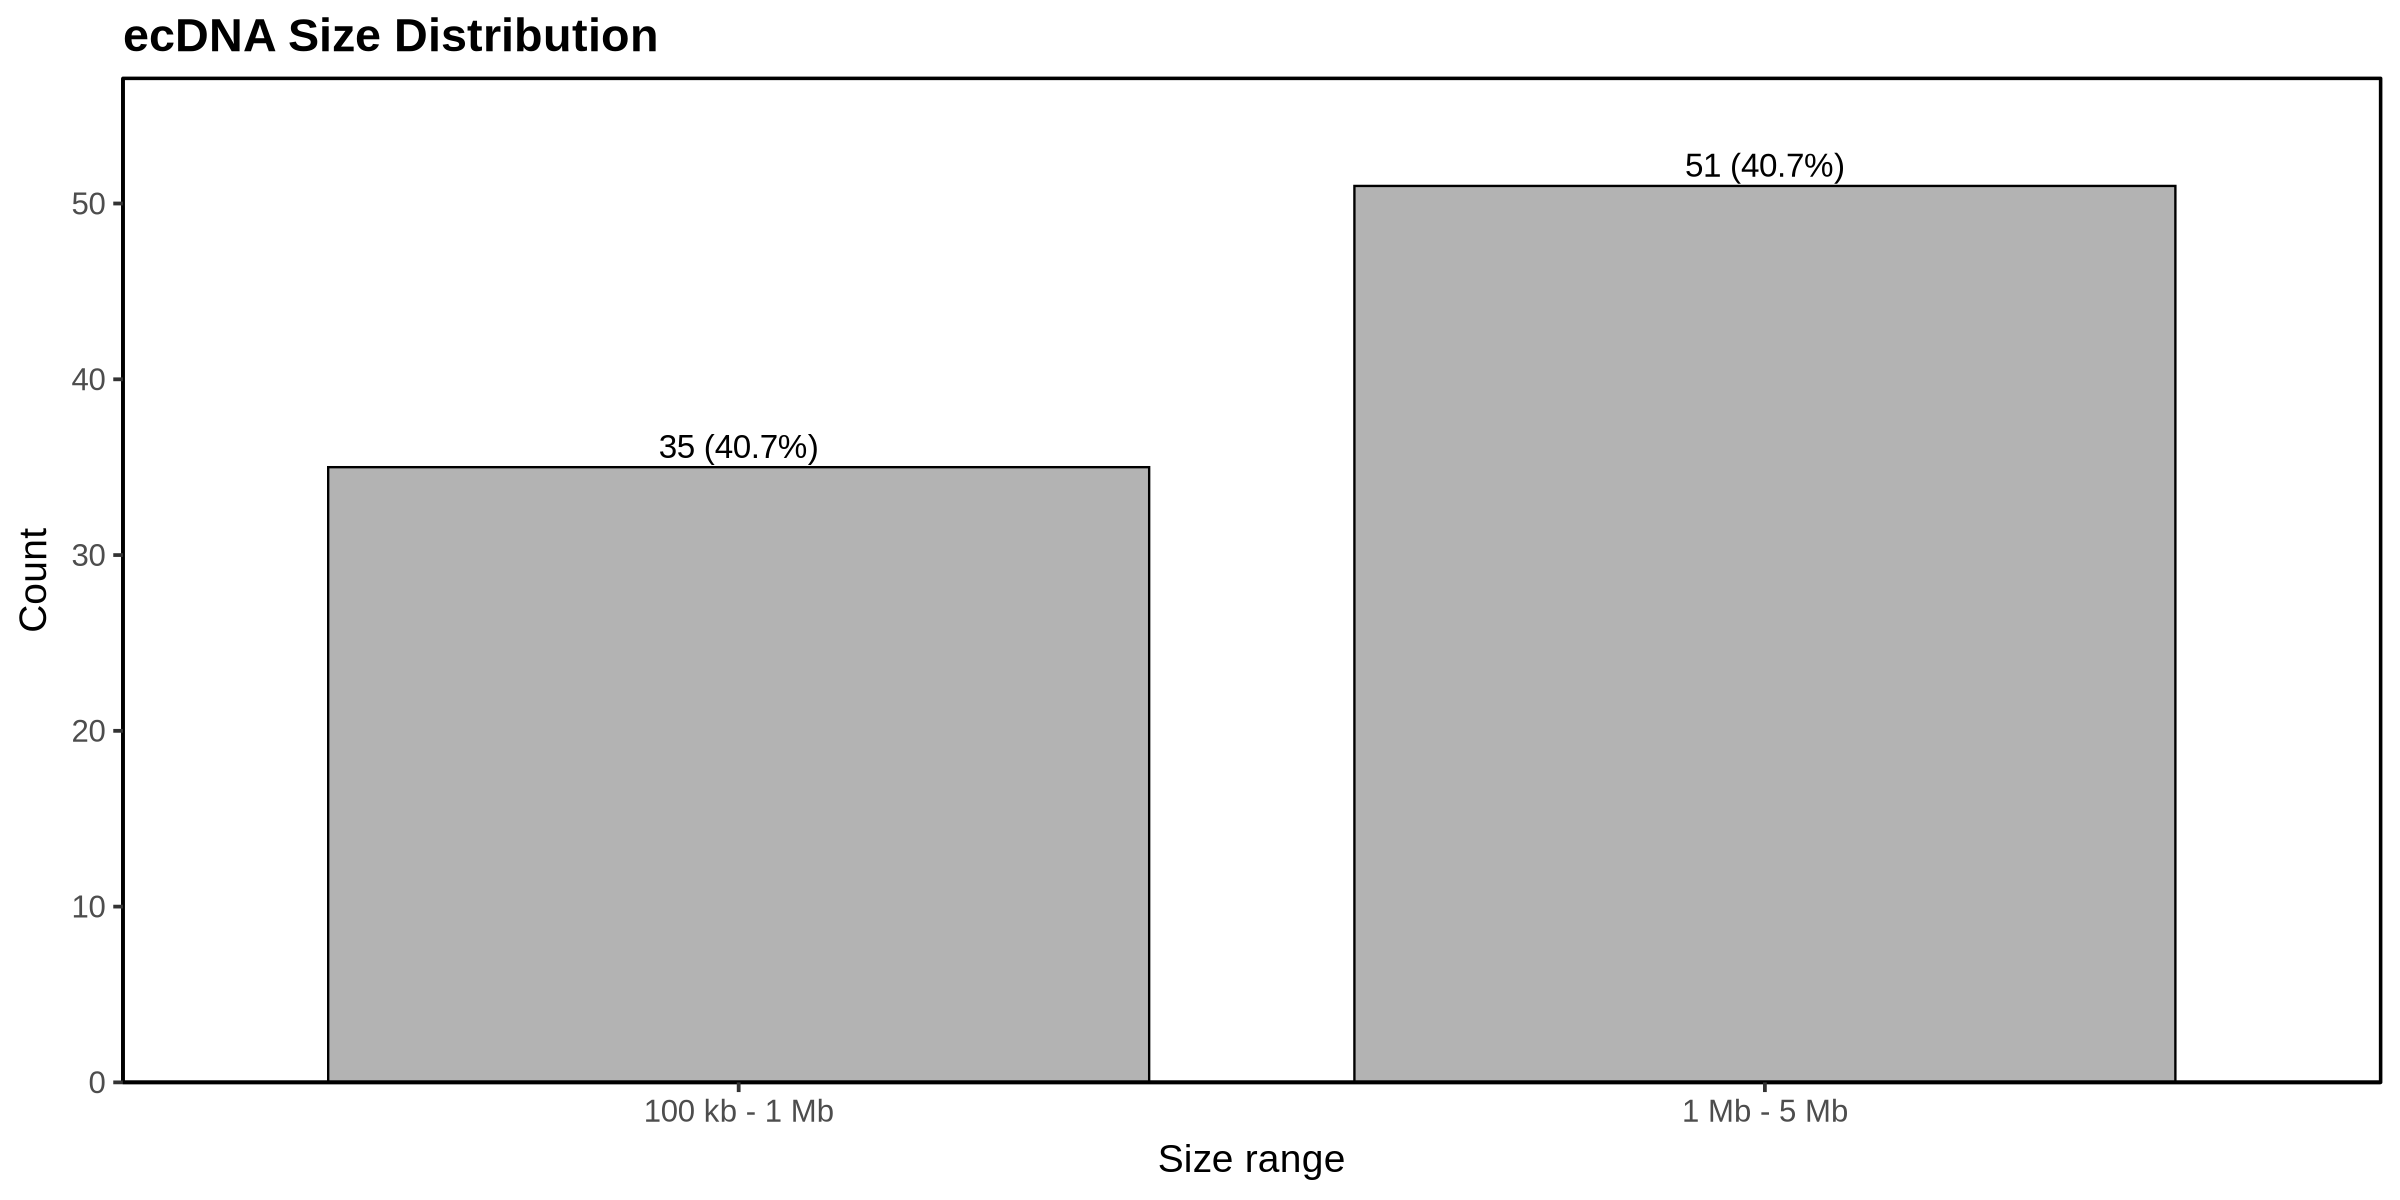

In [142]:

###### HARS size distribution
ecdna_data <- cnv_ecdna %>%
  filter(ecDNA_flag == 1 & Length >= 1000 & Length <= 5e6) %>%
  mutate(Length_kb = Length / 1000)  # convert bp to kb

# Define three size bins
bin_levels <- c( "100 kb - 1 Mb", "1 Mb - 5 Mb")

ecdna_binned <- ecdna_data %>%
  mutate(size_range = case_when(
    #Length_kb >= 1 & Length_kb < 100 ~ "1 kb - 100 kb",
    Length_kb >= 100 & Length_kb < 1000 ~ "100 kb - 1 Mb",
    Length_kb >= 1000 & Length_kb <= 5000 ~ "1 Mb - 5 Mb",
    TRUE ~ NA_character_
  )) %>%
  filter(!is.na(size_range)) %>%
  mutate(size_range = factor(size_range, levels = bin_levels))

#  Count ecDNAs per size range (include zero counts)
size_counts <- ecdna_binned %>%
  count(size_range, name = "count") %>%
  complete(size_range = factor(bin_levels, levels = bin_levels),
           fill = list(count = 0)) %>%
  mutate(pct = ifelse(sum(count) > 0, count / sum(count), 0))

# Plot
p <- ggplot(size_counts, aes(x = size_range, y = count)) +
  geom_col(width = 0.8, fill = "grey70", color = "black", linewidth = 0.4) +
  geom_text(
    aes(label = paste0(count, " (", percent(pct, accuracy = 0.1), ")")),
    vjust = -0.4, size = 4.2
  ) +
  labs(
    title = "ecDNA Size Distribution",
    x = "Size range",
    y = "Count"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12)), breaks = pretty_breaks()) +
  theme_classic(base_size = 14, base_family = "Helvetica") +
  theme(
    plot.title   = element_text(face = "bold", margin = margin(b = 6)),
    axis.title.x = element_text(margin = margin(t = 6)),
    axis.title.y = element_text(margin = margin(r = 6)),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
    legend.position = "none"
  ) +
  coord_cartesian(clip = "off")

# Display plot
p

#  Save plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/size_ecDNA_three_bins.pdf",
  plot = p,
  width = 6,
  height = 4,
  dpi = 300
)


In [143]:
# Load chr arm lengths
chr_arm_size <- read.csv("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")

# RTL matrix (assumes tab-delimited, sample IDs as rownames)
telomeres_MAD <- read.table("telomeres_MAD.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)

In [144]:
head(cnv_ecdna)
head(chr_arm_size)
head(telomeres_MAD)

ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>
2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0
2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1
2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0
2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0
2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0
2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0


,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,norm_TL,direction.y,direction
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,-0.06948662,Negative,Neutral
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,-0.21340301,Negative,Negative
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,-2.95775970,Negative,Neutral
4,3188,chr1q,3086.500,1,q,3.086500,Negative,chr1q,2824.125,399.500,0.65675845,Negative,Negative
5,3988,chr1p,2347.500,1,p,2.347500,Negative,chr1p,5689.500,1319.250,-2.53325753,Negative,Neutral
6,3988,chr1q,5083.000,1,q,5.083000,Negative,chr1q,5689.500,1319.250,-0.45973091,Negative,Negative


In [145]:

cnv_arms <- cnv_ecdna %>%
  mutate(chrom_chr = paste0("chr", chrom)) %>%
  rowwise() %>%
  mutate(
    Arm = chr_arm_size$Arm[
      chr_arm_size$Chromosome == chrom_chr &
      loc.end >= chr_arm_size$Start &   # CNV end is after arm start
      loc.start <= chr_arm_size$End     # CNV start is before arm end
    ][1]  # take first overlapping arm
  ) %>%
  ungroup()


In [146]:
head(cnv_arms)

ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,chrom_chr,Arm
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,chr1,p
2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,chr1,q
2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0,chr10,q
2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0,chr10,q
2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0,chr10,q
2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0,chr10,q


In [147]:

cnv_arms <- cnv_arms %>%
  mutate(chr_arm = paste0(chrom_chr, Arm)) %>%  # Merge last two columns
  dplyr::select(-chrom_chr, -Arm)                       # Remove the originals
head(cnv_arms)

ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,chr_arm
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,chr1p
2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,chr1q
2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0,chr10q
2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0,chr10q
2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0,chr10q
2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0,chr10q


In [148]:
write.table(cnv_arms,
            file = "/home/mjehangir/telomere-sv-analysis/data/HARs_with_chr-arms.txt",
            sep = "\t",
            quote = FALSE,
            row.names = FALSE)


In [149]:
# Step 2: Rename columns to match for merging
cnv_arms <- cnv_arms %>%
  dplyr::rename(Sample_prefix = ID)

In [150]:
# Step 3: Merge MAD and CNV arms by Sample_prefix and chr_arm
merged_data <- telomeres_MAD %>%
  inner_join(cnv_arms, by = c("Sample_prefix", "chr_arm"))

# Check result
head(merged_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,0
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,0
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,0
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,0


In [151]:

# Create the specific ecDNA-only summary
ecdna_arm_summary <- merged_data %>%
  group_by(Sample_prefix, chr_arm) %>%
  summarise(
    # 1. Binary status: Is there any ecDNA on this arm?
    ecDNA_Present = if_else(any(ecDNA_flag == 1), "Yes", "No"),
    
    # 2. Segment Count: Total number of independent segments flagged as 1
    ecDNA_Segments = sum(ecDNA_flag == 1, na.rm = TRUE),
    
    # 3. Total Footprint: Sum of Length for only the flagged segments (converted to Mb)
    ecDNA_Size_Mb = sum(Length[ecDNA_flag == 1], na.rm = TRUE) / 1e6,
    
    # 4. Average Amplification: Mean seg.mean of the ecDNA segments
    Avg_ecDNA_Amplification = mean(seg.mean[ecDNA_flag == 1], na.rm = TRUE),
    
    .groups = "drop"
  ) %>%
  # Filter to show only the arms that actually have ecDNA (flag = 1)
  filter(ecDNA_Present == "Yes") %>%
  arrange(desc(ecDNA_Size_Mb))

# View the final summary
print(ecdna_arm_summary)

# A tibble: 61 × 6
   Sample_prefix chr_arm ecDNA_Present ecDNA_Segments ecDNA_Size_Mb
   <chr>         <chr>   <chr>                  <int>         <dbl>
 1 6436B         chr3q   Yes                        5         13.0 
 2 6605D         chr8q   Yes                        5         11.6 
 3 6436B         chr10p  Yes                        5         10.8 
 4 6266D         chr10p  Yes                        3          9.21
 5 6324B         chr7q   Yes                        3          9.21
 6 3988          chr12p  Yes                        2          7.41
 7 6266D         chr12p  Yes                        2          7.41
 8 6439C         chr8q   Yes                        2          6.00
 9 6483C         chr8q   Yes                        3          5.40
10 6605D         chr10p  Yes                        2          4.41
# ℹ 51 more rows
# ℹ 1 more variable: Avg_ecDNA_Amplification <dbl>


In [152]:
# 1. Total number of ecDNA-positive arm regions (HARs)
total_ecdna_arms <- nrow(ecdna_arm_summary)

# 2. Total number of unique chromosomes involved
# (Extracts '1' from 'chr1p' to count unique chromosomes)
unique_chromosomes <- ecdna_arm_summary %>%
  mutate(chrom_num = str_extract(chr_arm, "chr[0-9XY]+")) %>%
  pull(chrom_num) %>%
  n_distinct()

# 3. Total number of samples that have at least one ecDNA arm
total_samples <- n_distinct(ecdna_arm_summary$Sample_prefix)

# Print the results to fill into your sentence
cat("Total HARs (ecDNA arms):", total_ecdna_arms, "\n")
cat("Unique Chromosomes:", unique_chromosomes, "\n")
cat("Total Samples affected:", total_samples, "\n")

Total HARs (ecDNA arms): 61 
Unique Chromosomes: 16 
Total Samples affected: 13 


In [153]:
# Find the top 3 most frequent ecDNA-positive arms
top_3_arms <- ecdna_arm_summary %>%
  group_by(chr_arm) %>%
  summarise(Frequency = n(), .groups = "drop") %>%
  arrange(desc(Frequency)) %>%
  slice_head(n = 3)

# Print the top 3
print("Top 3 Chromosome Arms for ecDNA formation:")
print(top_3_arms)

[1] "Top 3 Chromosome Arms for ecDNA formation:"
# A tibble: 3 × 2
  chr_arm Frequency
  <chr>       <int>
1 chr14q         11
2 chr15q         10
3 chr10q          5


In [205]:

# Make sure ecDNA_flag is a factor
merged_data <- merged_data %>%
  mutate(ecDNA_flag = factor(ecDNA_flag, levels = c(0,1), labels = c("No ecDNA","ecDNA")))

In [206]:
head(merged_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<fct>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,NA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,NA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,NA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,NA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,NA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,NA


In [158]:
write.table(merged_data,
            file = "/home/mjehangir/telomere-sv-analysis/data/TEL_merged_HARs_with_chr-arms.txt",
            sep = "\t",
            quote = FALSE,
            row.names = FALSE)


In [159]:
violin_df = merged_data

In [160]:
nrow(violin_df)

[1] 1900

In [161]:
violin_df %>% select(Sample_prefix, chr_arm, final_average_TL_p75, loc.start, loc.end, ecDNA_flag) %>%
filter(final_average_TL_p75 == 1642.500)


Sample_prefix,chr_arm,final_average_TL_p75,loc.start,loc.end,ecDNA_flag
<chr>,<chr>,<dbl>,<int>,<int>,<fct>
3188,chr1p,1642.5,200151,3002265,No ecDNA
3188,chr1p,1642.5,3202416,46034730,No ecDNA
3188,chr1p,1642.5,46234881,54641223,No ecDNA
3188,chr1p,1642.5,54841374,68051340,No ecDNA
3188,chr1p,1642.5,68251491,142507512,No ecDNA


In [162]:
nrow(violin_df)

[1] 1900

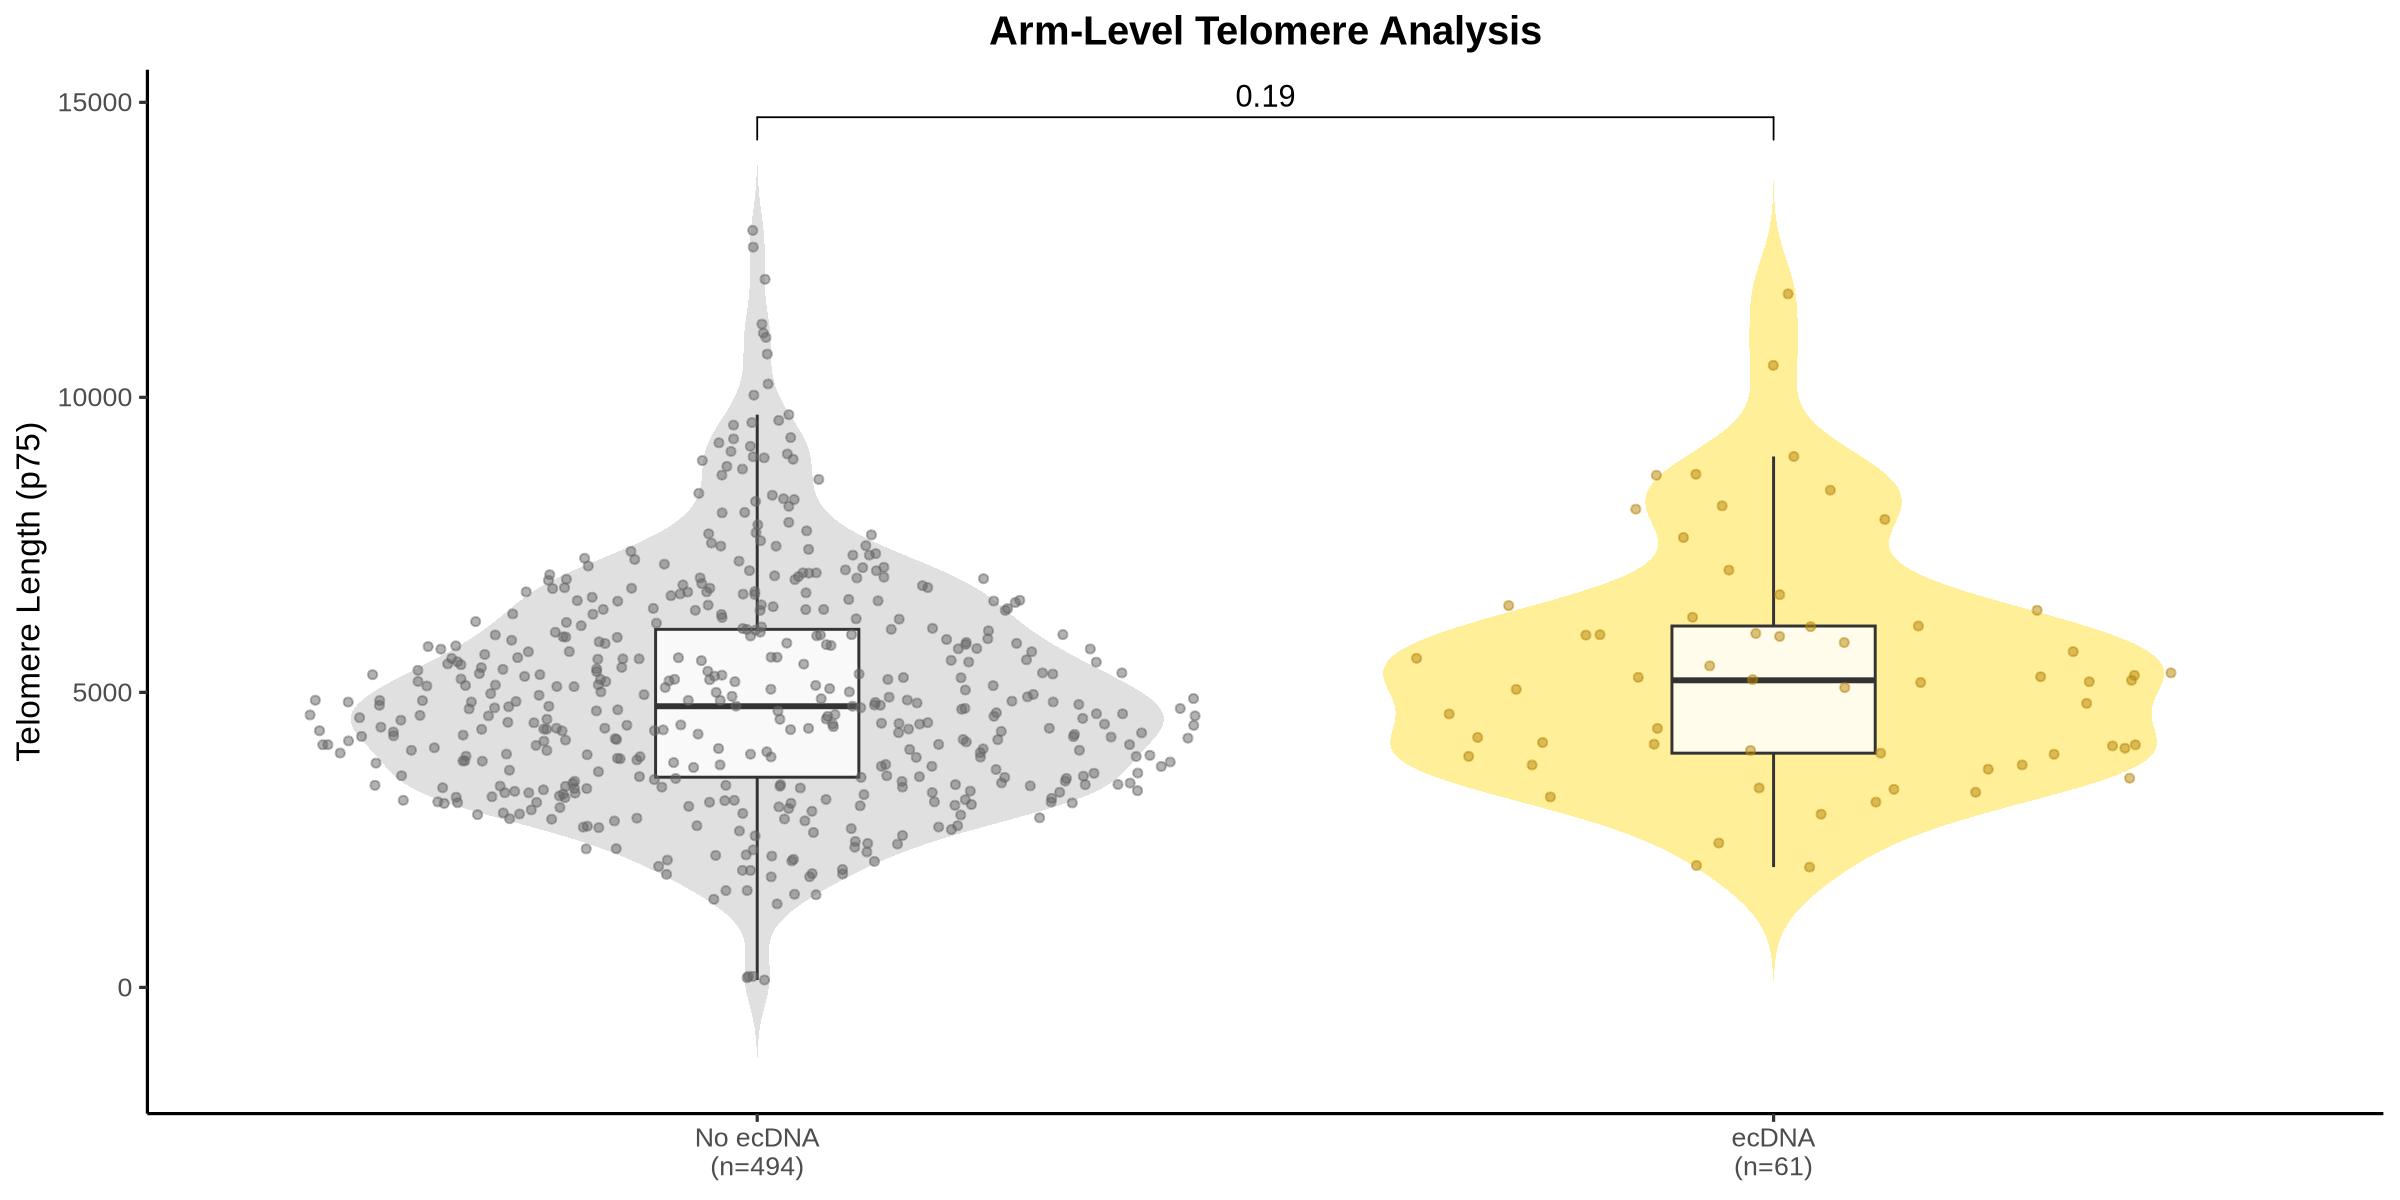

In [163]:


# ---- 1) Aggregation (Remove Pseudoreplication) ----
violin_df_clean <- violin_df %>%
  filter(!is.na(final_average_TL_p75)) %>%
  group_by(Sample_prefix, chr_arm) %>%
  summarise(
    # Take the first TL value since it's identical for all segments on this arm
    final_average_TL_p75 = dplyr::first(final_average_TL_p75),
    # If any segment on this arm is ecDNA, the whole arm counts as ecDNA
    ecDNA_status = if_else(any(ecDNA_flag %in% c(1, "1", "ecDNA")), "ecDNA", "No ecDNA"),
    .groups = "drop"
  ) %>%
  mutate(ecDNA_status = factor(ecDNA_status, levels = c("No ecDNA", "ecDNA")))

# ---- 2) Prepare Labels with n counts ----
counts <- table(violin_df_clean$ecDNA_status)
x_labels <- c(
  paste0("No ecDNA\n(n=", counts["No ecDNA"], ")"),
  paste0("ecDNA\n(n=", counts["ecDNA"], ")")
)

# ---- 3) Plotting ----
ymax <- max(violin_df_clean$final_average_TL_p75, na.rm = TRUE)

ggplot(violin_df_clean, aes(x = ecDNA_status, y = final_average_TL_p75, fill = ecDNA_status)) +
  # Geoms
  geom_violin(trim = FALSE, alpha = 0.4, color = NA, width = 0.8) +
  geom_boxplot(width = 0.2, outlier.shape = NA, alpha = 0.8, fill = "white") +
  geom_sina(aes(color = ecDNA_status), size = 1.2, alpha = 0.5) +
  # Scales & Themes
  scale_fill_manual(values = c("No ecDNA" = "grey70", "ecDNA" = "gold")) +
  scale_color_manual(values = c("No ecDNA" = "grey40", "ecDNA" = "#b8860b")) +
  scale_x_discrete(labels = x_labels) +
  labs(x = NULL, y = "Telomere Length (p75)", title = "Arm-Level Telomere Analysis") +
  theme_classic(base_size = 12) +
  theme(legend.position = "none", plot.title = element_text(hjust = 0.5, face = "bold")) +
  # Statistics
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(c("No ecDNA", "ecDNA")),
    label.y = 1.1 * ymax
  )

In [164]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/violinplot_ecDNa.pdf",
  plot = pB,
  width = 4,
  height = 6,
  dpi = 200
)


Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”


In [165]:
head(violin_df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<fct>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,No ecDNA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,ecDNA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,No ecDNA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,No ecDNA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,No ecDNA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,No ecDNA


In [167]:

# Prep
plot_df <- violin_df %>%
  mutate(
    seg.mean    = as.numeric(seg.mean),
    TL          = as.numeric(final_average_TL_p75),
    CNV_status  = factor(as.character(CNV_status),
                         levels = c("Loss","Neutral","Gain")),
    ecDNA_flag  = ifelse(as.character(ecDNA_flag) %in% c("1","ecDNA","TRUE","true"),
                         "ecDNA", "No ecDNA")
  )

# Decide x variable safely
log2_ok <- all(plot_df$seg.mean > 0, na.rm = TRUE)

plot_df <- plot_df %>%
  mutate(
    x_log2 = ifelse(seg.mean > 0, log2(seg.mean), NA_real_),
    x      = if (log2_ok) x_log2 else seg.mean
  ) %>%
  filter(is.finite(x), is.finite(TL))

x_lab <- if (log2_ok) "log2(seg.mean)" else "seg.mean (log2 copy-ratio)"

# Palettes
cnv_cols <- c("Loss"="#1f78b4", "Neutral"="#bdbdbd", "Gain"="#e31a1c")

# Build plot
p <- ggplot() +
  # Non-ecDNA points colored by CNV status
  geom_point(
    data = filter(plot_df, ecDNA_flag != "ecDNA"),
    aes(x = x, y = TL, color = CNV_status),
    alpha = 0.6, size = 1.5
  ) +
  # Trend line over all points
  geom_smooth(
    data = plot_df,
    aes(x = x, y = TL),
    method = "loess", se = TRUE, color = "black", linewidth = 0.8
  ) +
  # ecDNA points highlighted (gold with black border, bigger)
  geom_point(
    data = filter(plot_df, ecDNA_flag == "ecDNA"),
    aes(x = x, y = TL),
    inherit.aes = FALSE,
    shape = 21, fill = "gold", color = "black",
    size = 3.2, stroke = 0.5, alpha = 0.9
  ) +
  scale_color_manual(values = cnv_cols, name = "CNV status") +
  labs(x = x_lab, y = "Telomere Length (p75)") +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(color = "black"),
    axis.text.y = element_text(color = "black")
  )

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `x_log2 = ifelse(seg.mean > 0, log2(seg.mean), NA_real_)`.
Caused by warning in `ifelse()`:
! NaNs produced”


`geom_smooth()` using formula = 'y ~ x'


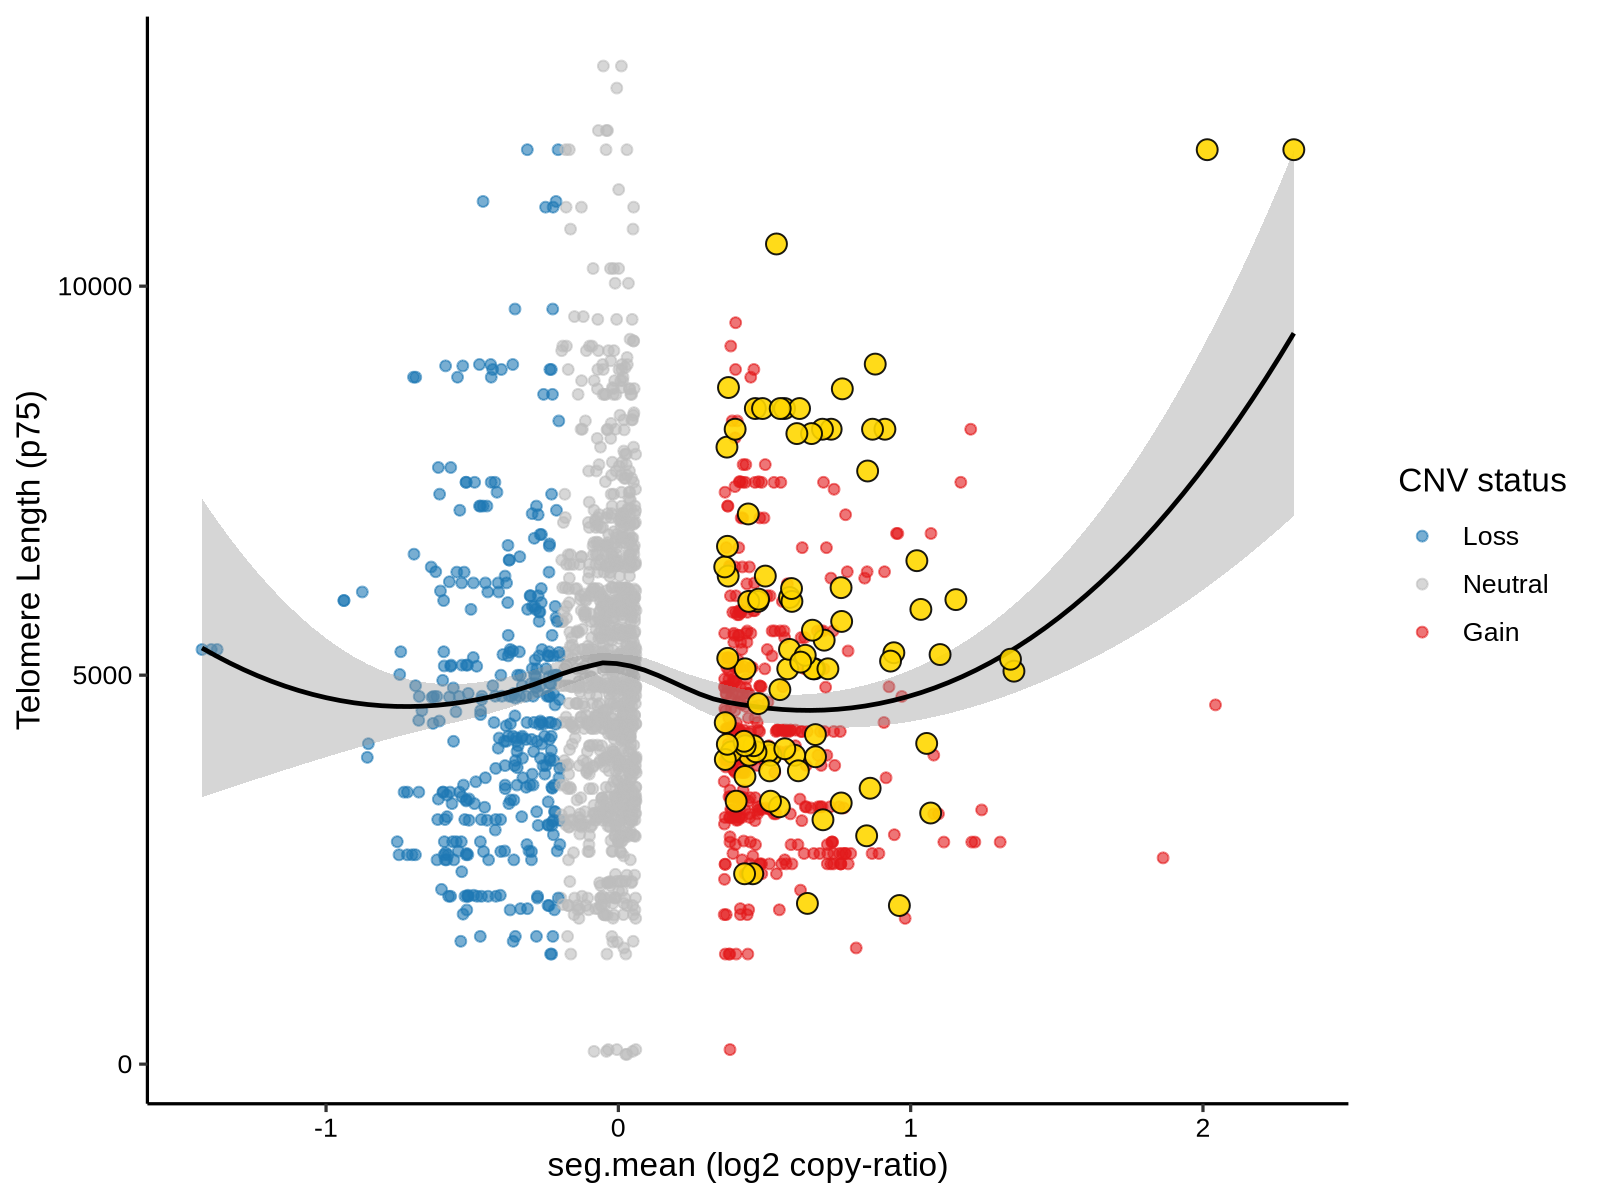

In [168]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)
print(p)

In [169]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/volcanoplot_ecDNa.pdf",
  plot = p,
  width = 8,
  height = 6,
  dpi = 200
)


`geom_smooth()` using formula = 'y ~ x'


In [170]:
head(violin_df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<fct>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,No ecDNA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,ecDNA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,No ecDNA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,No ecDNA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,No ecDNA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,No ecDNA


In [171]:
colnames(merged_data)

[1] "Sample_prefix"           "chr"                    
 [3] "final_average_TL_p75"    "chr_order"              
 [5] "arm"                     "final_average_TL_p75_kb"
 [7] "direction.x"             "chr_arm"                
 [9] "median_TL"               "mad_TL"                 
[11] "norm_TL"                 "direction.y"            
[13] "direction"               "chrom"                  
[15] "loc.start"               "loc.end"                
[17] "num.mark"                "seg.mean"               
[19] "Length"                  "CNV_status"             
[21] "med_seg"                 "mad_seg"                
[23] "ecDNA_flag"

In [172]:
nrow(merged_data)

[1] 1900

In [173]:
ecDna_DF = merged_data %>% filter(ecDNA_flag == "ecDNA") %>% dplyr::select(Sample_prefix, chr, loc.start, loc.end)

In [174]:
head(ecDna_DF)

,Sample_prefix,chr,loc.start,loc.end
,<chr>,<chr>,<int>,<int>
1,2436A,chr1q,142707663,142907814
2,6483C,chr2q,139255680,140856320
3,6436B,chr3q,141674763,143275603
4,6436B,chr3q,143475708,145676863
5,6436B,chr3q,145876968,146677388
6,6436B,chr3q,146877493,151279803


In [175]:
nrow(ecDna_DF)

[1] 85

In [176]:
head(merged_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<fct>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,No ecDNA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,ecDNA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,No ecDNA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,No ecDNA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,No ecDNA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,No ecDNA


In [177]:
ecDna_DF = merged_data %>% filter(ecDNA_flag == "ecDNA") %>% dplyr::select(Sample_prefix, chr, loc.start, loc.end, final_average_TL_p75)

In [178]:
head(ecDna_DF)

,Sample_prefix,chr,loc.start,loc.end,final_average_TL_p75
,<chr>,<chr>,<int>,<int>,<dbl>
1,2436A,chr1q,142707663,142907814,5051.167
2,6483C,chr2q,139255680,140856320,3141.000
3,6436B,chr3q,141674763,143275603,5081.417
4,6436B,chr3q,143475708,145676863,5081.417
5,6436B,chr3q,145876968,146677388,5081.417
6,6436B,chr3q,146877493,151279803,5081.417


In [179]:
unique(ecDna_DF$chr)

[1] "chr1q"  "chr2q"  "chr3q"  "chr5q"  "chr5p"  "chr7q"  "chr7p"  "chr8q" 
 [9] "chr9p"  "chr9q"  "chr10p" "chr10q" "chr11q" "chr11p" "chr12p" "chr13q"
[17] "chr14q" "chr15q" "chr17q" "chr17p" "chr19p" "chr22q"

In [180]:


# ===== Count per chromosome =====
tab_single <- ecDna_DF %>%
  mutate(base_chr = sub("^(chr[0-9XY]+).*", "\\1", chr)) %>%
  count(base_chr, name = "n") %>%
  arrange(desc(n)) %>%
  mutate(
    rank = row_number(),
    pct  = n / sum(n)
  )

# ===== Assign colors: top-3 red, others grey =====
n_rows <- nrow(tab_single)
n_grey <- max(n_rows - 3L, 0L)
greys  <- if (n_grey > 0L) gray.colors(n_grey, start = 0.85, end = 0.5) else character(0)
tab_single$fill_col <- c("red1", "red2", "red3", greys)[seq_len(n_rows)]

# ===== Labels only for top-3 slices =====
label_df <- tab_single %>%
  filter(rank <= 3) %>%
  mutate(lbl = paste0(base_chr, " ", percent(pct, accuracy = 0.1)))


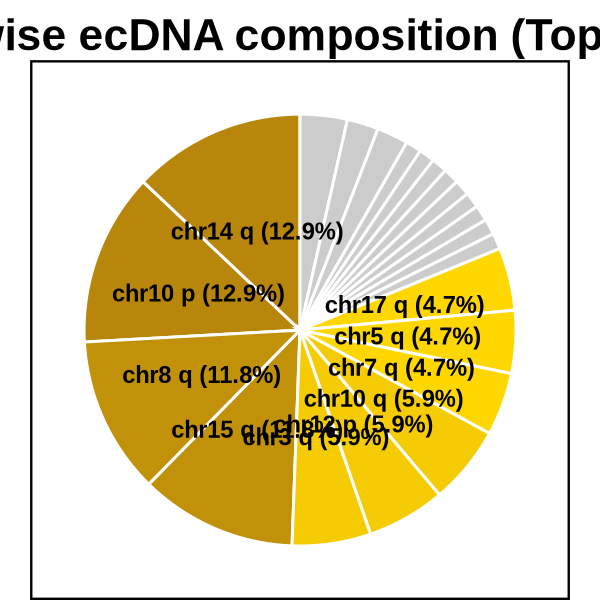

In [215]:
# ==============================
# ecDNA Pie: Top-7 gold, others grey
# ==============================

tab_all <- ecDna_DF %>%
  mutate(
    arm      = sub(".*(p|q)$", "\\1", chr),          # extract "p" or "q"
    base_chr = sub("^(chr[0-9XY]+).*", "\\1", chr), # extract chromosome name
    chr_arm  = paste(base_chr, arm, sep = " ")      # combine for labeling
  ) %>%
  filter(arm %in% c("p","q")) %>%
  count(chr_arm, name = "n") %>%
  arrange(desc(n)) %>%
  mutate(
    pct  = n / sum(n),
    rank = row_number(),
    lbl  = ifelse(rank <= 10, paste0(chr_arm, " (", percent(pct, accuracy = 0.1), ")"), "")
  )

# ------------------------------
# Assign colors
# ------------------------------
top_n <- 10
tab_all$fill_col <- ifelse(
  tab_all$rank <= top_n,
  scales::col_numeric(
    palette = c("#FFD700", "#B8860B"), # gold to darkgoldenrod
    domain  = c(min(tab_all$pct[1:top_n]), max(tab_all$pct[1:top_n]))
  )(tab_all$pct[1:top_n]),
  "grey80" # others in light grey
)
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 200)

# ------------------------------
# Plot pie chart
# ------------------------------
q <- ggplot(tab_all, aes(x = "", y = pct, fill = fill_col)) +
  geom_col(color = "white", linewidth = 0.5, width = 1) +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = lbl),
    position = position_stack(vjust = 0.5),
    size = 3,
    color = "black",
    fontface = "bold"
  ) +
  scale_fill_identity() +
  theme_void(base_size = 14) +
  theme(
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    plot.title   = element_text(face = "bold", hjust = 0.5, size = 16)
  ) +
  labs(title = "Chromosome arm-wise ecDNA composition (Top 7 gold, others grey)")
q

In [182]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/piechart_ecDNa.pdf",
  plot = q,
  width = 6,
  height = 6,
  dpi = 200
)


In [183]:
head(ecDna_DF)

,Sample_prefix,chr,loc.start,loc.end,final_average_TL_p75
,<chr>,<chr>,<int>,<int>,<dbl>
1,2436A,chr1q,142707663,142907814,5051.167
2,6483C,chr2q,139255680,140856320,3141.000
3,6436B,chr3q,141674763,143275603,5081.417
4,6436B,chr3q,143475708,145676863,5081.417
5,6436B,chr3q,145876968,146677388,5081.417
6,6436B,chr3q,146877493,151279803,5081.417


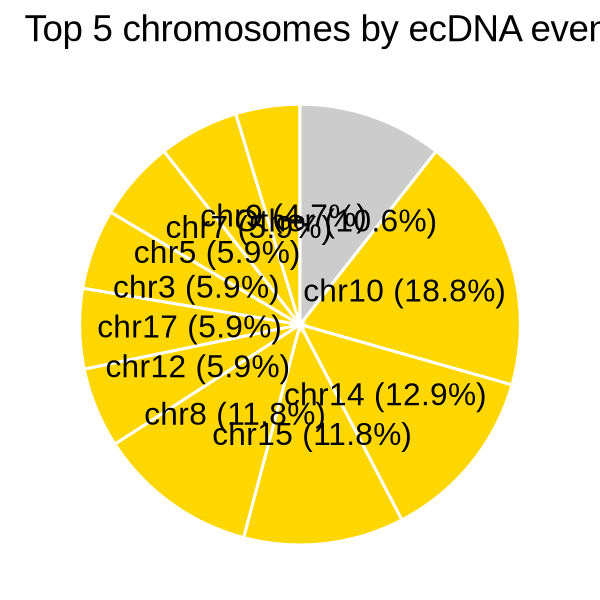

In [216]:
library(dplyr)
library(ggplot2)
library(scales)

# ------------------------------
# 1. Merge p/q into whole chromosome
# ------------------------------
ecDNA_chr <- violin_df %>%
  filter(ecDNA_flag != "No ecDNA") %>%   # only ecDNA segments
  mutate(chr = as.character(sub("^(chr[0-9XY]+)[pq]$", "\\1", chr_arm)))

# ------------------------------
# 2. Count events per chromosome
# ------------------------------
chr_counts <- ecDNA_chr %>%
  group_by(chr) %>%
  summarise(num_events = n(), .groups = "drop") %>%
  arrange(desc(num_events))

# ------------------------------
# 3. Split top 5 + Others without slice()
# ------------------------------
top_n <- 10
top5 <- head(chr_counts, top_n)
other_sum <- sum(chr_counts$num_events) - sum(top5$num_events)
other <- data.frame(chr = "Other", num_events = other_sum)

chr_counts_plot <- bind_rows(top5, other) %>%
  mutate(
    pct = num_events / sum(num_events),
    label = paste0(chr, " (", percent(pct, 0.1), ")"),
    fill_color = ifelse(chr == "Other", "grey80", "gold")
  )
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 200)

# ------------------------------
# 4. Pie chart
# ------------------------------
ggplot(chr_counts_plot, aes(x = "", y = pct, fill = fill_color)) +
  geom_col(color = "white", width = 1) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 4) +
  scale_fill_identity() +
  theme_void() +
  ggtitle("Top 5 chromosomes by ecDNA events (gold) and Others (grey)")


In [217]:
head(violin_df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<fct>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,No ecDNA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,ecDNA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,No ecDNA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,No ecDNA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,No ecDNA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,No ecDNA


In [218]:
colnames(violin_df)

[1] "Sample_prefix"           "chr"                    
 [3] "final_average_TL_p75"    "chr_order"              
 [5] "arm"                     "final_average_TL_p75_kb"
 [7] "direction.x"             "chr_arm"                
 [9] "median_TL"               "mad_TL"                 
[11] "norm_TL"                 "direction.y"            
[13] "direction"               "chrom"                  
[15] "loc.start"               "loc.end"                
[17] "num.mark"                "seg.mean"               
[19] "Length"                  "CNV_status"             
[21] "med_seg"                 "mad_seg"                
[23] "ecDNA_flag"

In [219]:
head(violin_df$chr_arm)
head(violin_df$arm)

[1] "chr1p" "chr1q" "chr1p" "chr1p" "chr1p" "chr1p"

[1] "p" "q" "p" "p" "p" "p"

In [232]:
#######COMPARE HARS WITH TELOMERS
# =========================
# 1) Prepare data
# =========================
dat <- violin_df %>%
  dplyr::transmute(
    chr_arm     = as.character(chr_arm),        # e.g., "chr1p"
    arm         = as.character(arm),            # "p"/"q" (not used here)
    TL          = final_average_TL_p75,
    ecDNA_flag  = stringr::str_trim(as.character(ecDNA_flag))
  ) %>%
  dplyr::mutate(
    ecDNA_flag = factor(ecDNA_flag, levels = c("No ecDNA", "ecDNA"))
  ) %>%
  dplyr::filter(!is.na(chr_arm), chr_arm != "", !is.na(TL), !is.na(ecDNA_flag))

# =========================
# 2) Per-arm summaries for bars (mean ± SEM)
# =========================
summ <- dat %>%
  dplyr::group_by(chr_arm, ecDNA_flag) %>%
  dplyr::summarise(
    n       = dplyr::n(),
    mean_TL = mean(TL, na.rm = TRUE),
    sd_TL   = sd(TL,  na.rm = TRUE),
    sem_TL  = sd_TL / sqrt(n),
    .groups = "drop"
  )

# =========================
# 3) One-sided tests (H1: ecDNA > No ecDNA) per chr_arm
# =========================
tests <- dat %>%
  dplyr::group_by(chr_arm) %>%
  tidyr::nest() %>%
  dplyr::mutate(
    both_groups = purrr::map_lgl(data, ~ length(unique(.x$ecDNA_flag)) == 2),
    res = purrr::map2(data, both_groups, ~{
      if (!.y) {
        return(tibble(
          p = NA_real_, mean_diff = NA_real_,
          mean_ecDNA = NA_real_, mean_noecDNA = NA_real_
        ))
      }
      # group means
      m <- .x %>%
        dplyr::group_by(ecDNA_flag) %>%
        dplyr::summarise(m = mean(TL, na.rm = TRUE), .groups = "drop")
      mean_ecDNA   <- m$m[m$ecDNA_flag == "ecDNA"]
      mean_noecDNA <- m$m[m$ecDNA_flag == "No ecDNA"]

      # one-sided test; fallback to Wilcoxon if t-test errors
      pval <- tryCatch(
        t.test(TL ~ ecDNA_flag, data = .x, alternative = "greater") %>% broom::tidy() %>% dplyr::pull(p.value),
        error = function(e) wilcox.test(TL ~ ecDNA_flag, data = .x, alternative = "greater", exact = FALSE) %>% broom::tidy() %>% dplyr::pull(p.value)
      )

      tibble(
        p = pval,
        mean_diff = mean_ecDNA - mean_noecDNA,
        mean_ecDNA = mean_ecDNA,
        mean_noecDNA = mean_noecDNA
      )
    })
  ) %>%
  dplyr::select(-data) %>%
  tidyr::unnest(res) %>%
  dplyr::mutate(p_adj = p.adjust(p, method = "BH")) %>%
  dplyr::arrange(dplyr::desc(mean_diff))

# =========================
# 4) Pick top 4 chr_arms to plot
# =========================
top_arms <- tests %>%
  dplyr::filter(!is.na(p_adj), mean_diff > 0, p_adj < 0.05) %>%
  dplyr::slice_head(n = 4) %>%           # already ordered by mean_diff desc
  dplyr::pull(chr_arm)

# If none significant after BH, fall back to top 4 positive diffs
if (length(top_arms) == 0) {
  top_arms <- tests %>%
    dplyr::filter(!is.na(mean_diff), mean_diff > 0) %>%
    dplyr::slice_head(n = 4) %>%
    dplyr::pull(chr_arm)
}

plot_summ  <- summ  %>% dplyr::filter(chr_arm %in% top_arms)
plot_dat   <- dat   %>% dplyr::filter(chr_arm %in% top_arms)
plot_tests <- tests %>% dplyr::filter(chr_arm %in% top_arms)

# =========================
# 5) Build stats table (exactly one row per facet)
# =========================
stat_tbl <- plot_tests %>%
  dplyr::transmute(
    chr_arm,
    group1 = "No ecDNA",
    group2 = "ecDNA",
    p = p_adj,
    label = paste0("q=", signif(p_adj, 3), "\n\u0394=", round(mean_diff, 1))  # Δ
  ) %>%
  dplyr::group_by(chr_arm) %>%
  dplyr::slice_head(n = 1) %>%   # avoid IRanges::slice by naming dplyr::slice_head
  dplyr::ungroup()

# y-position per facet: a bit above tallest bar + SEM
ypos_tbl <- plot_summ %>%
  dplyr::group_by(chr_arm) %>%
  dplyr::summarise(y.position = max(mean_TL + sem_TL, na.rm = TRUE) * 1.08, .groups = "drop")

stat_tbl <- stat_tbl %>% dplyr::left_join(ypos_tbl, by = "chr_arm")



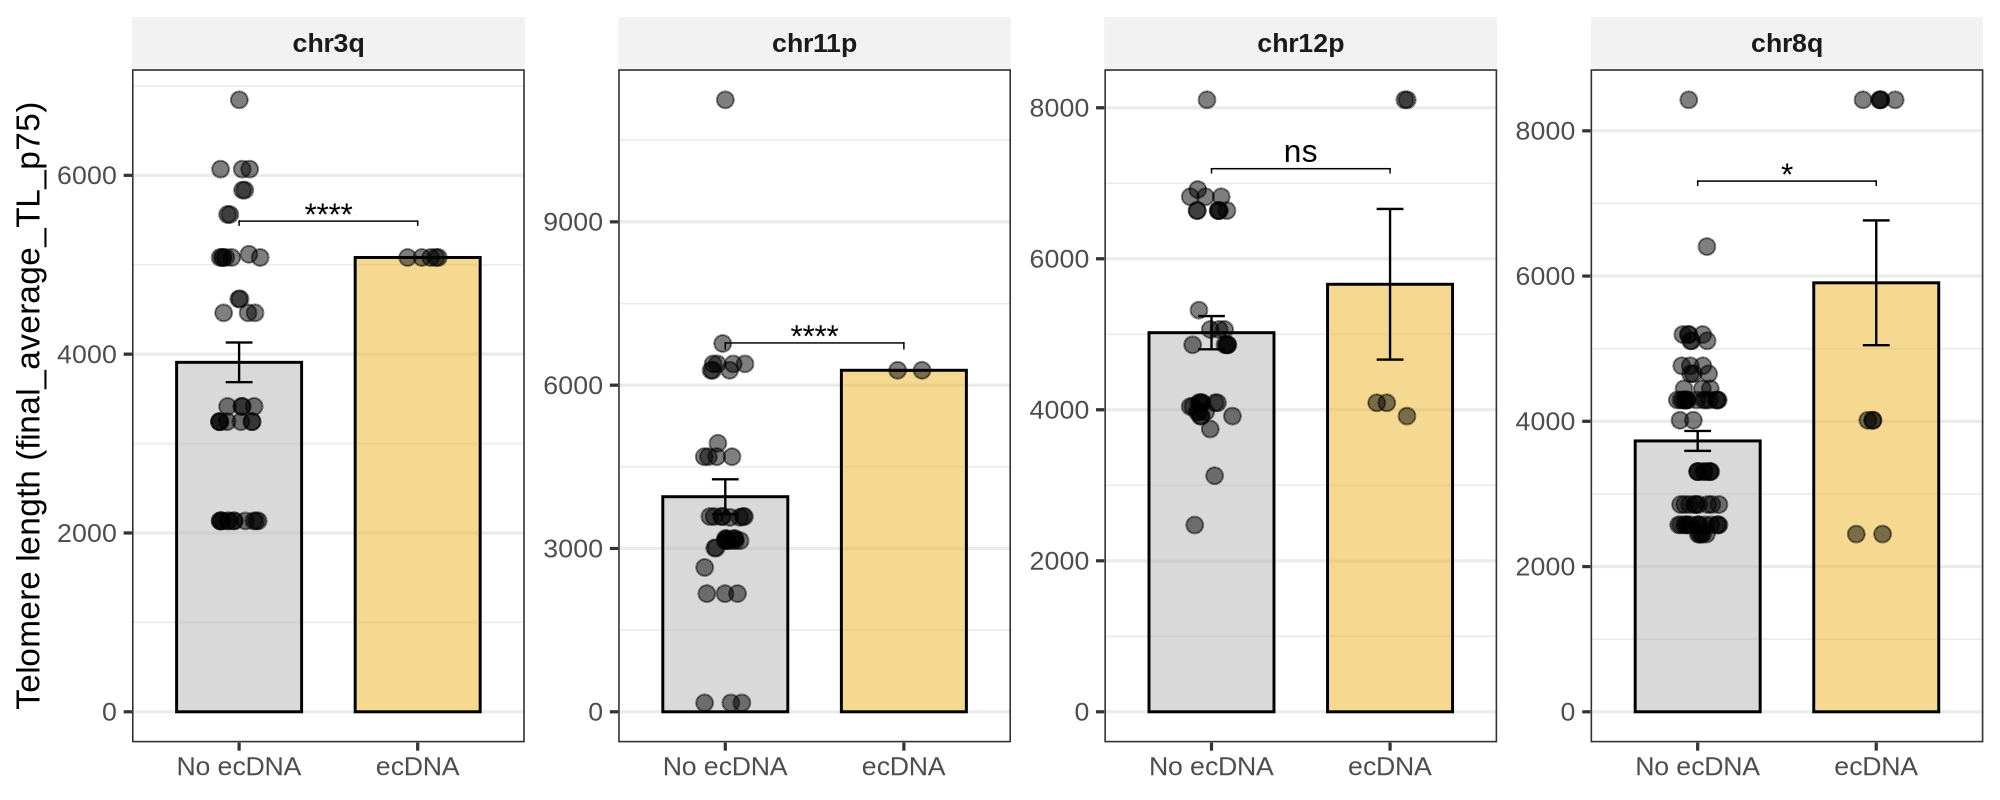

In [233]:


# Arms to show (in this order)
arms_keep <- c("chr3q", "chr11p", "chr12p", "chr8q")

pd <- plot_dat %>%
  filter(chr_arm %in% arms_keep) %>%
  mutate(
    chr_arm = factor(chr_arm, levels = arms_keep),
    ecDNA_flag = factor(as.character(ecDNA_flag), levels = c("No ecDNA", "ecDNA"))
  )

# Per-arm summaries (mean ± SEM) for bars
summ_pd <- pd %>%
  group_by(chr_arm, ecDNA_flag) %>%
  summarise(
    n = n(),
    mean_TL = mean(TL, na.rm = TRUE),
    sd_TL   = sd(TL,  na.rm = TRUE),
    sem_TL  = sd_TL / sqrt(n),
    .groups = "drop"
  )

# Two-sided t-test per facet (no BH). ggpubr gives p, p.signif (stars), p.format
tests <- ggpubr::compare_means(
  TL ~ ecDNA_flag,
  group.by = "chr_arm",
  data = pd,
  method = "t.test",
  ref.group = "No ecDNA",  # not required for t-test stars, but keeps direction consistent
  paired = FALSE
) %>%
  # Keep only the rows comparing the two groups
  filter(group1 == "No ecDNA", group2 == "ecDNA") %>%
  mutate(label = p.signif)

# y-positions: a bit above tallest bar+SEM in each facet
ypos_tbl <- summ_pd %>%
  group_by(chr_arm) %>%
  summarise(y.position = max(mean_TL + sem_TL, na.rm = TRUE) * 1.08, .groups = "drop")

stat_tbl <- tests %>%
  dplyr::select(chr_arm, group1, group2, label) %>%
  left_join(ypos_tbl, by = "chr_arm")

cols <- c("No ecDNA" = "grey70", "ecDNA" = "goldenrod2")

options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 200)

pd <- ggplot() +
  # bars (means) with black border and alpha 0.5
  geom_col(
    data = summ_pd,
    aes(x = ecDNA_flag, y = mean_TL, fill = ecDNA_flag),
    width = 0.7,
    color = "black",
    alpha = 0.5
  ) +
  # SEM error bars
  geom_errorbar(
    data = summ_pd,
    aes(x = ecDNA_flag, ymin = mean_TL - sem_TL, ymax = mean_TL + sem_TL),
    width = 0.15, linewidth = 0.4
  ) +
  # dots (each observation), alpha = 0.5
  geom_jitter(
    data = pd,
    aes(x = ecDNA_flag, y = TL),
    width = 0.12, height = 0, alpha = 0.5, size = 2.5
  ) +
  # p-value stars per facet
  ggpubr::stat_pvalue_manual(
    stat_tbl,
    label = "label",
    y.position = "y.position",
    xmin = "group1",
    xmax = "group2",
    tip.length = 0.01,
    bracket.size = 0.25,
    size = 4,
    inherit.aes = FALSE
  ) +
  scale_fill_manual(values = cols, guide = "none") +
  facet_wrap(~ chr_arm, nrow = 1, scales = "free_y") +
  labs(x = NULL, y = "Telomere length (final_average_TL_p75)") +
  theme_bw(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey95", colour = NA),
    strip.text = element_text(face = "bold"),
    panel.grid.major.x = element_blank()
  )
pd

In [222]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/barplots_ecDNa.pdf",
  plot = pd,
  width = 12,
  height = 4,
  dpi = 200
)


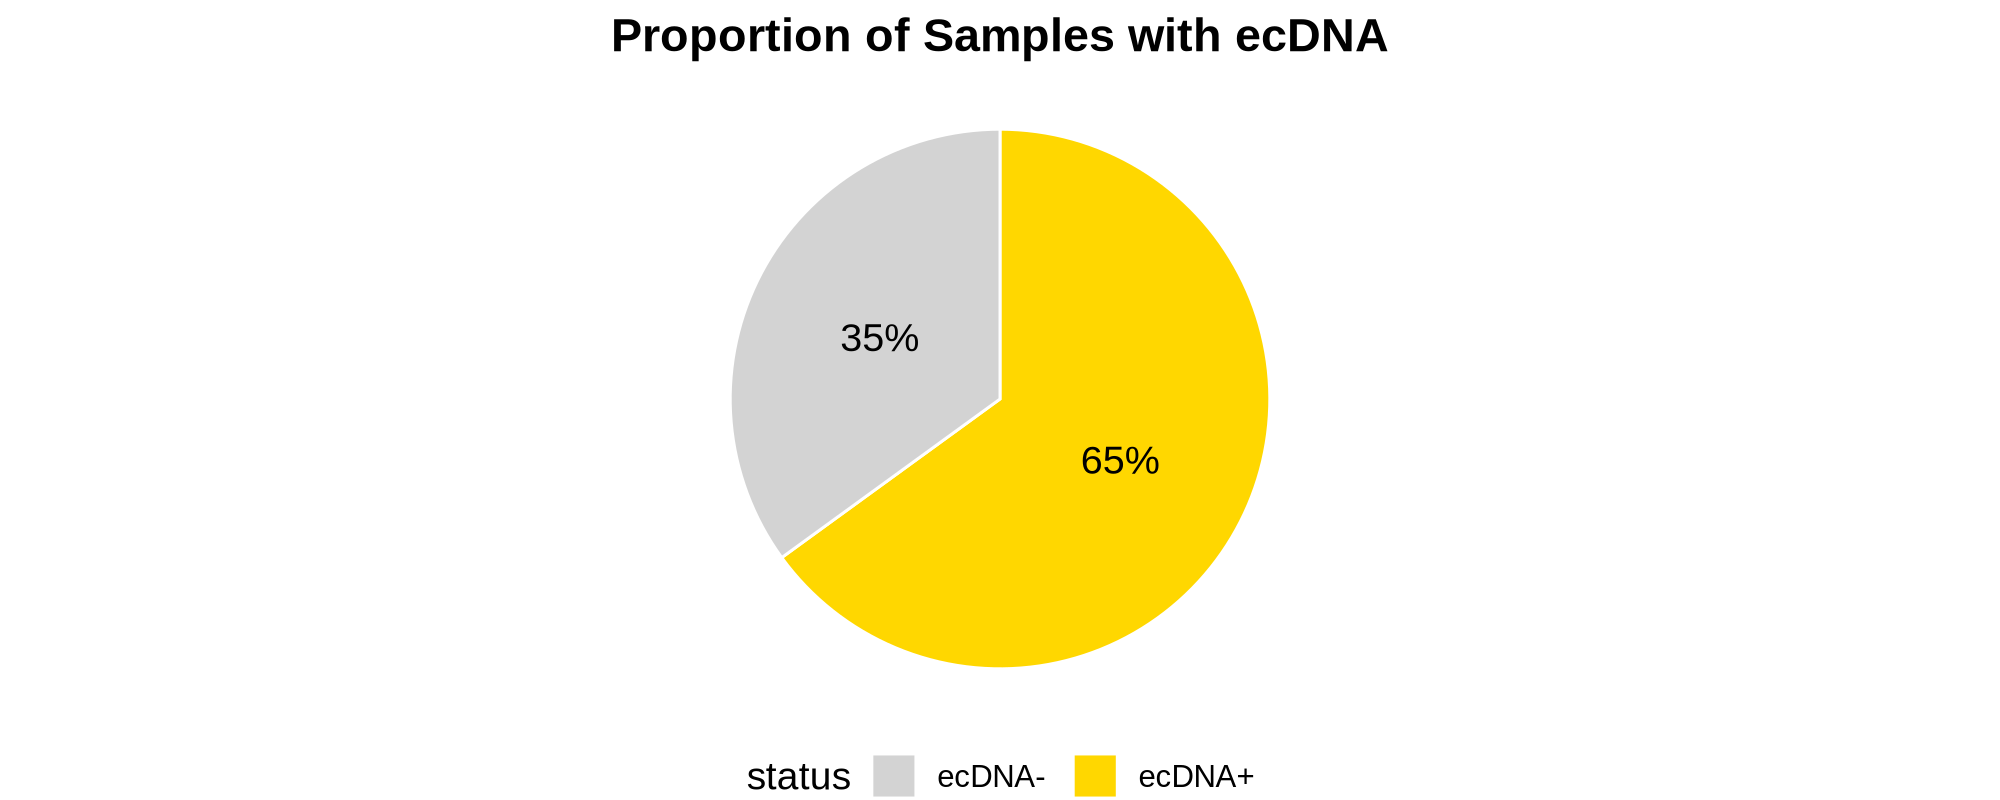

In [223]:
library(dplyr)
library(ggplot2)

# 1. Summarize cohort-level ecDNA status
ecdna_cohort <- cnv_ecdna %>%
  group_by(ID) %>%
  summarize(has_ecDNA = any(ecDNA_flag == 1), .groups = "drop") %>%
  mutate(status = ifelse(has_ecDNA, "ecDNA+", "ecDNA-")) %>%
  count(status) %>%
  mutate(percentage = n / sum(n) * 100)

# 2. Pie chart
p <- ggplot(ecdna_cohort, aes(x = "", y = percentage, fill = status)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(aes(label = paste0(round(percentage,1), "%")),
            position = position_stack(vjust = 0.5), size = 5) +
  scale_fill_manual(values = c("ecDNA+" = "gold", "ecDNA-" = "lightgrey")) +
  theme_void(base_size = 14) +
  labs(title = "Proportion of Samples with ecDNA") +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "bottom"
  )
p

In [194]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/piechart_ecDNa_conposition.pdf",
  plot = p,
  width = 6,
  height = 6,
  dpi = 200
)


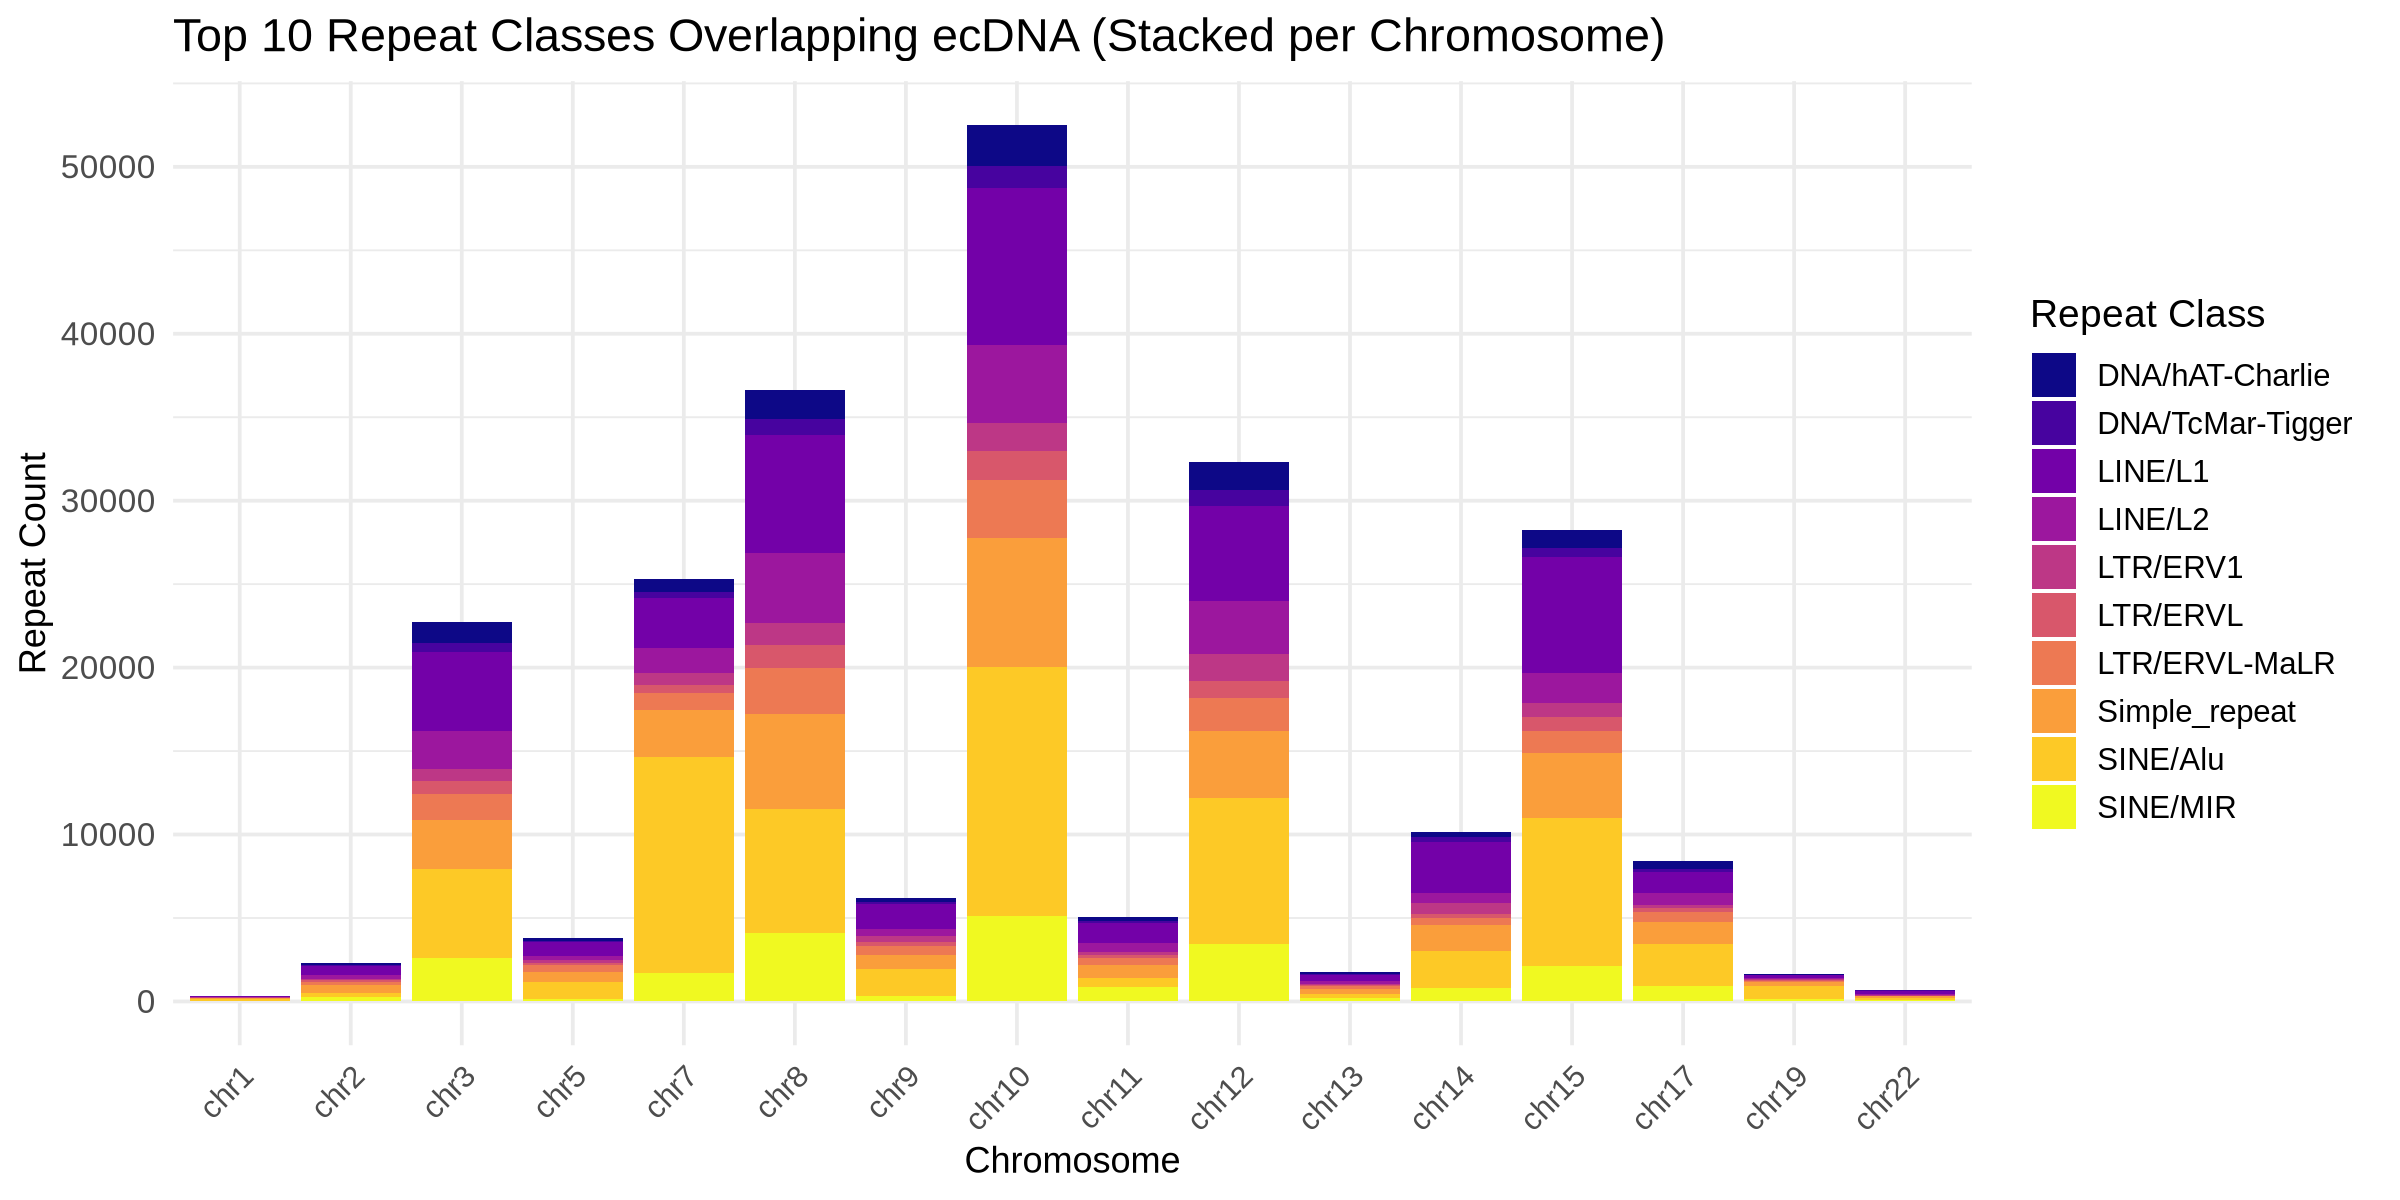

In [212]:
####HARs REPREATS ANNOTATION
repeats <- read.delim("/home/mjehangir/softwares/SVAN/chm13/REPEATS_chm13.bed", 
                      header = TRUE, comment.char = "#")

# Convert repeats to GRanges
repeats_gr <- GRanges(
  seqnames = repeats$ref,
  ranges   = IRanges(start = repeats$beg, end = repeats$end),
  class    = repeats$class,
  family   = repeats$family
)

# --------------------------
# 2. Overlaps with ecDNA (gr_q should be your ecDNA GRanges)
# --------------------------
hits <- findOverlaps(repeats_gr, gr_q)
repeats_ecdna <- repeats[queryHits(hits), ]

# --------------------------
# 3. Summarize overall top 10 repeat classes
# --------------------------
repeat_summary <- repeats_ecdna %>%
  group_by(class) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(desc(count)) %>%
  slice_max(count, n = 10)

top_classes <- repeat_summary$class

# --------------------------
# 4. Summarize per chromosome for top classes
# --------------------------
repeat_summary_chr <- repeats_ecdna %>%
  filter(class %in% top_classes) %>%
  group_by(ref, class) %>%
  summarise(count = n(), .groups = "drop")

# Optional: order chromosomes naturally
repeat_summary_chr$ref <- factor(
  repeat_summary_chr$ref,
  levels = mixedsort(unique(repeat_summary_chr$ref))
)

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

# --------------------------
# 5A. Stacked bar plot per chromosome
# --------------------------
p1 <- ggplot(repeat_summary_chr, aes(x = ref, y = count, fill = class)) +
  geom_bar(stat = "identity") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Top 10 Repeat Classes Overlapping ecDNA (Stacked per Chromosome)",
    x = "Chromosome",
    y = "Repeat Count",
    fill = "Repeat Class"
  ) +
  scale_fill_viridis_d(option = "plasma") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(size = 12),
    axis.title  = element_text(size = 13)
  )



p1

In [ ]:
p1

In [208]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/HARs_repeats.pdf",
  plot = p1,
  width = 6,
  height = 4,
  dpi = 200
)

ERROR: Error: object 'p_sorted' not found


In [ ]:
repeat_summary

In [229]:
nrow(filtered_data)

[1] 634

In [230]:
# ===============================================
# ecDNA Annotation: Genes and Repeats per Chromosome
# ===============================================
# ---------- Helper: safe BED reader ----------
read_bed_any <- function(path) {
  df <- suppressWarnings(readr::read_tsv(
    path, col_names = FALSE, comment = "#", show_col_types = FALSE, progress = FALSE
  ))
  names(df)[1:3] <- c("chrom","start0","end")
  if (!all(grepl("^chr", df$chrom))) df$chrom <- paste0("chr", df$chrom)
  
  df <- df |>
    mutate(start0 = suppressWarnings(as.integer(start0)),
           end    = suppressWarnings(as.integer(end))) |>
    filter(!is.na(start0), !is.na(end), end > start0)
  
  gr <- GRanges(seqnames = df$chrom,
                ranges   = IRanges(start = df$start0 + 1L, end = df$end))
  if (ncol(df) >= 4) mcols(gr)$name <- as.character(df[[4]])
  if (ncol(df) >= 5) mcols(gr)$geneName <- as.character(df[[5]])
  if (ncol(df) >= 6) mcols(gr)$biotype <- as.character(df[[6]])
  gr
}

# ---------- Normalize chromosome names ----------
normalize_chr <- function(gr) {
  seqlevels(gr) <- gsub("^chrchr", "chr", seqlevels(gr)) # remove double "chr"
  gr
}

# ---------- Prepare ecDNA GRanges ----------
stopifnot(all(c("chr","loc.start","loc.end","Sample_prefix") %in% names(ecDna_DF)))

qry <- ecDna_DF %>%
  transmute(
    Sample_prefix,
    chr_orig = chr,
    base_chr = sub("^(chr[0-9XY]+).*", "\\1", chr),
    q_start  = as.integer(loc.start),
    q_end    = as.integer(loc.end)
  ) %>%
  filter(!is.na(base_chr), !is.na(q_start), !is.na(q_end), q_end >= q_start)

gr_q <- GRanges(seqnames = qry$base_chr, ranges = IRanges(qry$q_start, qry$q_end))
mcols(gr_q) <- S4Vectors::DataFrame(
  qid           = seq_len(nrow(qry)),
  Sample_prefix = qry$Sample_prefix,
  chr_orig      = qry$chr_orig,
  base_chr      = qry$base_chr
)

# ---------- Read exon and repeat BED ----------
base_dir <- "/home/mjehangir/softwares/SVAN/chm13"
gr_exon   <- read_bed_any(file.path(base_dir, "EXONS_chm13.bed"))
repeats_gr <- read_bed_any(file.path(base_dir, "REPEATS_chm13.bed"))

# Normalize chromosomes
gr_q       <- normalize_chr(gr_q)
gr_exon    <- normalize_chr(gr_exon)
repeats_gr <- normalize_chr(repeats_gr)

# ---------- Annotate ecDNA with exons ----------
ann_exon <- function(gr_query, gr_feat, prefix="EXON") {
  hits <- findOverlaps(gr_query, gr_feat, ignore.strand = TRUE)
  n_feat_vec <- integer(length(gr_query))
  overlap_bp_vec <- integer(length(gr_query))
  feat_vec <- vector("list", length(gr_query))
  
  if (length(hits) > 0) {
    n_feat_vec <- tabulate(queryHits(hits), nbins = length(gr_query))
    ov_gr <- pintersect(gr_query[queryHits(hits)], gr_feat[subjectHits(hits)])
    ov_bp <- tapply(width(ov_gr), queryHits(hits), sum)
    overlap_bp_vec[as.integer(names(ov_bp))] <- as.integer(ov_bp)
    by_q <- split(mcols(gr_feat)$geneName[subjectHits(hits)], queryHits(hits))
    feat_vec[as.integer(names(by_q))] <- lapply(by_q, unique)
  }
  
  tibble(
    qid = mcols(gr_query)$qid,
    !!paste0(prefix, "_overlap_bp")   := overlap_bp_vec,
    !!paste0(prefix, "_overlap_frac") := overlap_bp_vec / width(gr_query),
    !!paste0(prefix, "_n_features")   := n_feat_vec,
    !!paste0(prefix, "_genes")        := feat_vec
  )
}

ann_exon_df <- ann_exon(gr_q, gr_exon)

# ---------- Annotate ecDNA with repeats ----------
hits_repeats <- findOverlaps(gr_q, repeats_gr, ignore.strand = TRUE)

repeat_annot <- tibble(
  qid = mcols(gr_q)$qid,
  repeat_class = vector("list", length(gr_q)),
  repeat_family = vector("list", length(gr_q))
)

if (length(hits_repeats) > 0) {
  by_q <- split(subjectHits(hits_repeats), queryHits(hits_repeats))
  for (i in seq_along(gr_q)) {
    if (i %in% names(by_q)) {
      idx <- by_q[[as.character(i)]]
      repeat_annot$repeat_class[[i]]  <- mcols(repeats_gr)$name[idx]   # keep all repeats
      repeat_annot$repeat_family[[i]] <- mcols(repeats_gr)$geneName[idx]
    }
  }
}

# Convert empty lists to NA for unnesting
repeat_annot <- repeat_annot %>%
  mutate(repeat_class = lapply(repeat_class, function(x) if(length(x)==0) NA else x))

# ---------- Combine annotations ----------
annot_combined <- as_tibble(mcols(gr_q)) %>%
  mutate(
    q_start = start(gr_q),
    q_end   = end(gr_q),
    q_width = width(gr_q)
  ) %>%
  left_join(ann_exon_df, by = "qid") %>%
  left_join(repeat_annot, by = "qid")

# ---------- Summarize per chromosome ----------
# Genes
genes_per_chr <- annot_combined %>%
  filter(!map_lgl(EXON_genes, is.null)) %>%
  unnest(EXON_genes) %>%
  group_by(base_chr) %>%
  summarise(n_genes = n_distinct(EXON_genes), .groups = "drop")

# Repeats (count all repeats per chromosome)
repeats_per_chr <- annot_combined %>%
  filter(!map_lgl(repeat_class, is.null)) %>%
  unnest(repeat_class) %>%
  group_by(base_chr) %>%
  summarise(n_repeats = n(), .groups = "drop")   # count total repeats

# Merge and tidy
summary_chr <- full_join(genes_per_chr, repeats_per_chr, by = "base_chr") %>%
  tidyr::replace_na(list(n_genes=0, n_repeats=0)) %>%
  mutate(base_chr = factor(base_chr, levels = mixedsort(unique(base_chr))))

summary_long <- summary_chr %>%
  pivot_longer(cols = c(n_genes, n_repeats), names_to = "feature", values_to = "count") %>%
  mutate(feature = recode(feature, n_genes="Genes", n_repeats="Repeats"))




In [114]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)


In [236]:

# Natural chromosome order
summary_long <- summary_long %>%
  mutate(base_chr = factor(base_chr, levels = mixedsort(unique(base_chr))))

# NG-style dodge bars with log y-axis
p <- ggplot(summary_long, aes(x = base_chr, y = count, fill = feature)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  scale_y_continuous(trans = "pseudo_log",   # shows small gene counts alongside large repeats
                     breaks = c(1,10,100,1000,10000,50000),
                     labels = scales::comma) +
  scale_fill_manual(values = c("Genes" = "maroon", "Repeats" = "wheat3")) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.position = "top",
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(
    x = "Chromosome",
    y = "Count of Overlapping Features",
    fill = "Feature",
    title = "Genes and Repeats Overlapping ecDNA per Chromosome"
  ) +
  geom_text(aes(label = ifelse(feature=="Genes", count, NA)),
            position = position_dodge(width = 0.8),
            vjust = -0.3,
            size = 3)


Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_text()`).”


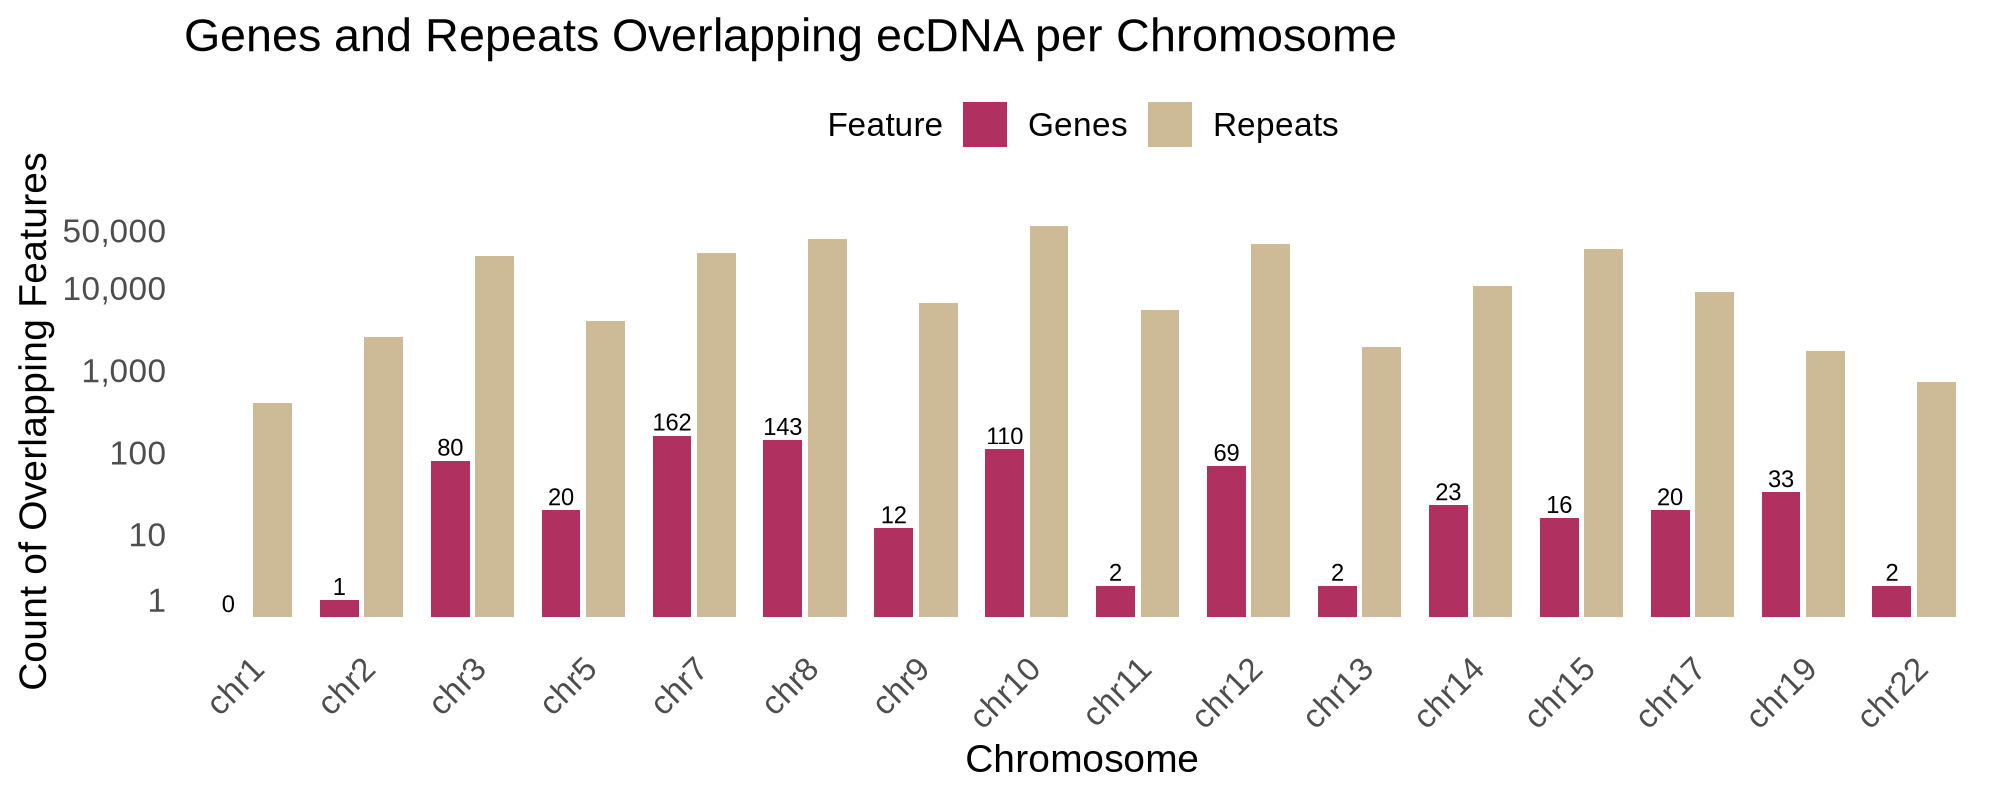

In [237]:
p

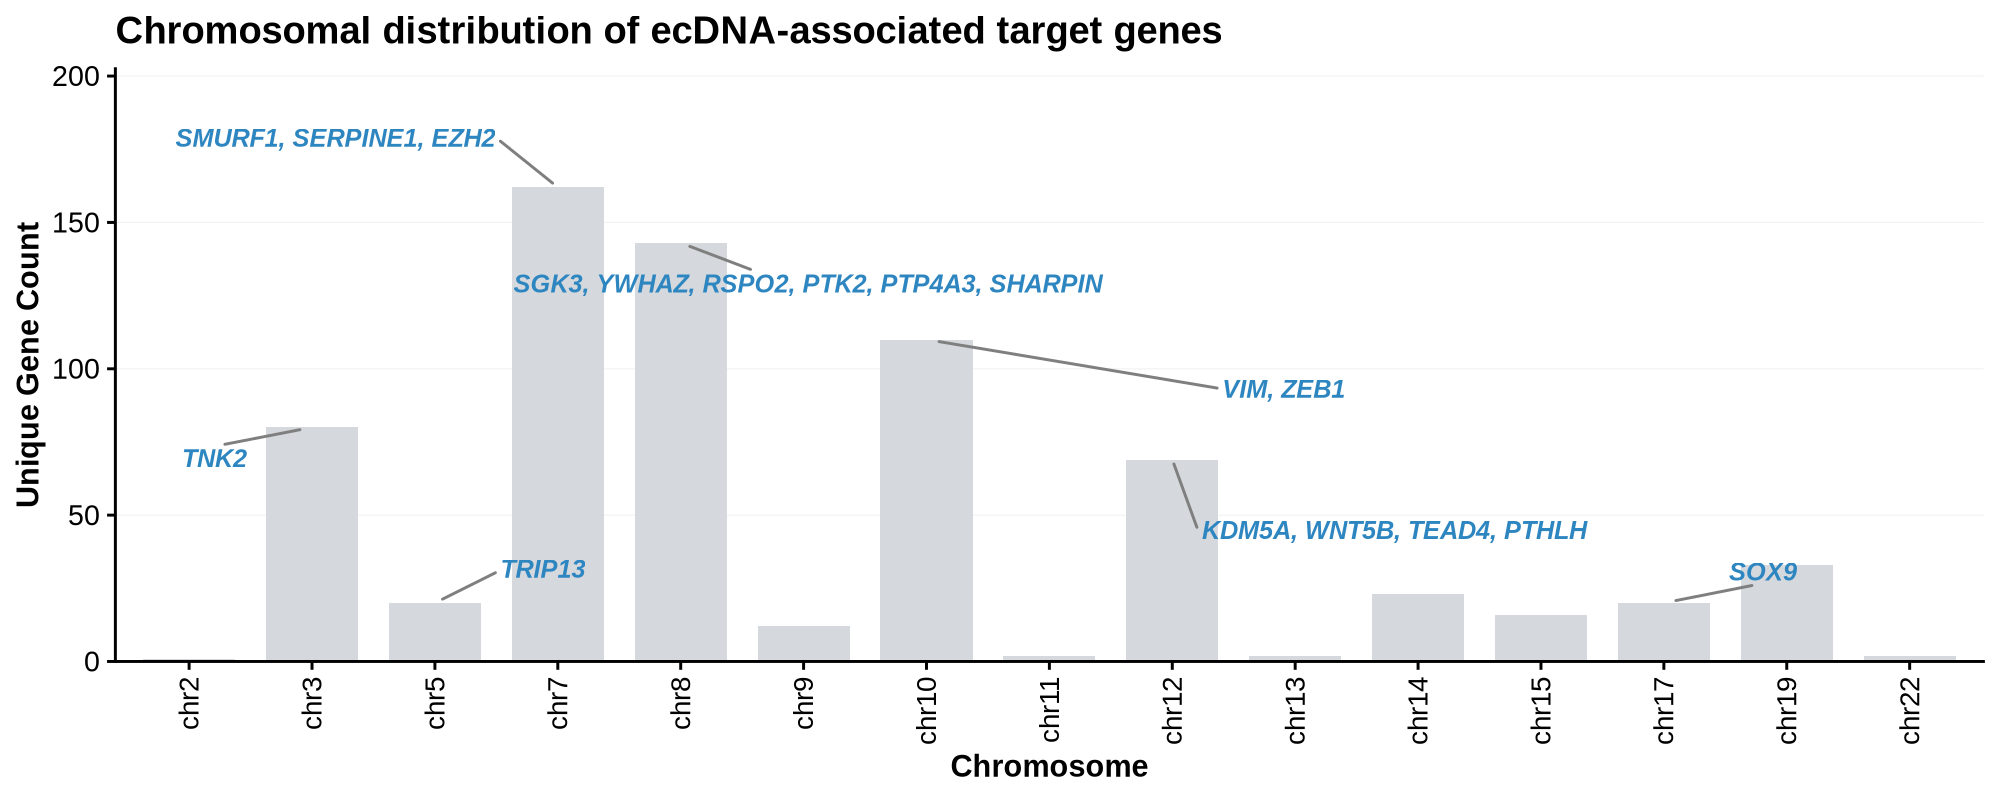

In [238]:

# 1. Define the specific gene list from your image
target_genes <- c(
  "EZH2", "TEAD4", "KDM5A", "PTK2", "TNK2", "PTP4A3", 
  "SGK3", "TRIP13", "ZEB1", "SOX9", "RSPO2", "YWHAZ", 
  "VIM", "SERPINE1", "SMURF1", "SHARPIN", "PTHLH", "WNT5B"
)

# 2. Process Data: Summarize genes and extract specific "Pop-up" labels
plot_data <- annot_exon_only %>%
  unnest(EXON_genes) %>%
  group_by(base_chr) %>%
  summarise(
    total_genes = n_distinct(EXON_genes),
    # Identify which genes from your specific list are on this chromosome
    found_targets = paste(intersect(unique(EXON_genes), target_genes), collapse = ", "),
    .groups = "drop"
  ) %>%
  # Natural Sort: chr1, chr2 ... chrX
  mutate(base_chr = factor(base_chr, levels = mixedsort(unique(as.character(base_chr)))))

# 3. Create the Nature-Style Chromosome Plot
p_targets <- ggplot(plot_data, aes(x = base_chr, y = total_genes)) +
  # Muted background bars for general gene distribution
  geom_bar(stat = "identity", fill = "#D5D8DC", width = 0.75) +
  
  # The "Pop-up": Annotation for your specific genes
  geom_text_repel(
    aes(label = found_targets),
    data = subset(plot_data, found_targets != ""),
    color = "#2E86C1",        # Professional blue for specific targets
    fontface = "bold.italic", # Genes must be italicized
    size = 3.2,
    box.padding = 1.5,
    point.padding = 0.5,
    min.segment.length = 0,   # Always draw a line to the bar
    segment.color = "grey50",
    segment.linetype = "solid",
    force = 3                 # Push labels away from each other
  ) +
  
  # Professional theme
  theme_cowplot(font_size = 12) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 10),
    axis.title = element_text(face = "bold", size = 11),
    panel.grid.major.y = element_line(color = "grey95", linewidth = 0.2)
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.25)), # Extra space at top for labels
    labels = scales::comma
  ) +
  labs(
    x = "Chromosome",
    y = "Unique Gene Count",
    title = "Chromosomal distribution of ecDNA-associated target genes"
  )

print(p_targets)

In [122]:
# Save the plot
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/genes-repeats_ecDNa.pdf",
  plot = p_targets,
  width = 8,
  height = 4,
  dpi = 200
)